# Momentum Strategies Backtest MOEX

Backtest of five momentum strategies on Russian equities (MOEX universe, 100 stocks): cross-sectional momentum (Jegadeesh & Titman 1993), time-series momentum (Moskowitz et al. 2012), Frog-in-the-Pan (Da et al. 2014), GLM momentum (Kim 2020), and residual momentum (Blitz et al. 2011). Data: daily and monthly OHLC prices, 2015--2024.

In [47]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from datetime import datetime, timedelta
from scipy import stats
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

from data_cache import get_stocks, get_index, RU_UNIVERSE_100, MOEX_INDEX

# Transaction costs (Тинькофф Trader)
COMMISSION_PCT = 0.0005
SLIPPAGE_PCT   = 0.0008
COST_ONE_WAY   = COMMISSION_PCT + SLIPPAGE_PCT   # 0.13%
COST_RT        = COST_ONE_WAY * 2                # 0.26% round-trip

# Risk-free proxy (RUSFAR / money market)
RF_ANNUAL  = 0.16
RF_MONTHLY = (1 + RF_ANNUAL) ** (1/12) - 1

START_DATE = '2022-01-01'

np.random.seed(42)
print('Setup OK')

Setup OK


In [48]:
# daily candles + index
print(' Загрузка дневных свечей ')
stocks_raw = get_stocks(RU_UNIVERSE_100, interval=24, start=START_DATE, verbose=False)
print(f'Загружено: {len(stocks_raw):,} свечей, {stocks_raw["ticker"].nunique()} тикеров')
print(f'Период: {stocks_raw["timestamp"].min().date()} -- {stocks_raw["timestamp"].max().date()}')

# Index
imoex_raw = get_index(MOEX_INDEX, interval=24, start=START_DATE, verbose=False)
print(f'\nIMOEX: {len(imoex_raw)} свечей')

=== Загрузка дневных свечей ===
Загружено: 124,049 свечей, 109 тикеров
Период: 2022-01-03 — 2026-06-15

IMOEX: 1111 свечей


In [49]:
# Build price matrices (daily & monthly)
# --- Daily close prices (wide matrix) ---
stocks_raw['date'] = pd.to_datetime(stocks_raw['timestamp'].dt.date)
daily_close = stocks_raw.pivot_table(index='date', columns='ticker',
                                      values='close', aggfunc='last')
daily_ret = daily_close.pct_change()

# --- Monthly prices (last trading day of month) ---
monthly_close = daily_close.resample('ME').last()
monthly_ret   = monthly_close.pct_change()

# --- IMOEX monthly ---
imoex_raw['date'] = pd.to_datetime(imoex_raw['timestamp'].dt.date)
imoex_daily = imoex_raw.set_index('date')['close'].sort_index()
imoex_daily = imoex_daily[~imoex_daily.index.duplicated(keep='last')]
imoex_monthly = imoex_daily.resample('ME').last().pct_change().rename('IMOEX')

# --- Equal-weight benchmark ---
ew_benchmark = monthly_ret.mean(axis=1).rename('EW_bench')

# --- Filter: require min 60 trading days in last 3 months for liquidity ---
MIN_HISTORY_MONTHS = 13  # need at least 13 months for 12-1 signal

T = len(monthly_ret)
N = monthly_ret.shape[1]
print(f'Daily matrix:   {daily_close.shape[0]} days × {daily_close.shape[1]} tickers')
print(f'Monthly matrix: {T} months × {N} tickers')
print(f'Period: {monthly_ret.index[0].date()} -- {monthly_ret.index[-1].date()}')
print(f'Avg tickers/month with data: {monthly_ret.count(axis=1).mean():.0f}')
print(f'\nIMOEX monthly returns: {imoex_monthly.dropna().shape[0]} months')

Daily matrix:   1213 days × 109 tickers
Monthly matrix: 54 months × 109 tickers
Period: 2022-01-31 — 2026-06-30
Avg tickers/month with data: 102

IMOEX monthly returns: 53 months


In [50]:
# Common backtest engine & metrics

def portfolio_metrics(returns, rf_monthly=RF_MONTHLY, name='Strategy'):
    """
    Compute comprehensive portfolio metrics from monthly returns series.
    Returns dict with annualized metrics.
    """
    r = returns.dropna()
    if len(r) < 6:
        return None
    n = len(r)
    
    # Basic
    mean_m   = r.mean()
    std_m    = r.std(ddof=1)
    ann_ret  = (1 + mean_m) ** 12 - 1
    ann_vol  = std_m * np.sqrt(12)
    
    # Sharpe (vs risk-free)
    excess = r - rf_monthly
    sharpe = excess.mean() / excess.std(ddof=1) * np.sqrt(12) if excess.std() > 0 else 0
    
    # Sortino (downside vol only)
    downside = excess[excess < 0]
    down_vol = np.sqrt((downside ** 2).mean()) * np.sqrt(12)
    sortino  = (ann_ret - RF_ANNUAL) / down_vol if down_vol > 0 else 0
    
    # Drawdown
    cum = (1 + r).cumprod()
    dd  = (cum.cummax() - cum) / cum.cummax()
    max_dd = dd.max()
    
    # Calmar = ann_ret / max_dd
    calmar = ann_ret / max_dd if max_dd > 0 else 0
    
    # t-stat on mean monthly return
    t_stat = mean_m / (std_m / np.sqrt(n))
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))
    
    # Win rate
    win_rate = (r > 0).mean()
    
    return {
        'name': name,
        'n_months': n,
        'ann_ret': ann_ret,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_dd': max_dd,
        'calmar': calmar,
        'mean_monthly': mean_m,
        't_stat': t_stat,
        'p_value': p_value,
        'win_rate': win_rate,
        'skew': r.skew(),
        'kurtosis': r.kurtosis(),
    }


def alpha_vs_benchmark(strat_returns, bench_returns, rf_monthly=RF_MONTHLY,
                       n_bootstrap=5000):
    """
    Test alpha of strategy vs benchmark.
    Returns: alpha, t-stat, p-values (parametric + bootstrap), Information Ratio.
    """
    # Align
    common = strat_returns.dropna().index.intersection(bench_returns.dropna().index)
    s = strat_returns.loc[common].values
    b = bench_returns.loc[common].values
    alpha = s - b
    n = len(alpha)
    if n < 6:
        return None
    
    # Parametric
    t_stat, p_param = stats.ttest_1samp(alpha, 0)
    
    # Bootstrap
    obs_mean = alpha.mean()
    centered = alpha - obs_mean
    boot_means = np.array([
        np.random.choice(centered, size=n, replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    p_boot = (np.abs(boot_means) >= np.abs(obs_mean)).mean()
    
    # Information Ratio (annualized)
    ir = obs_mean / alpha.std(ddof=1) * np.sqrt(12) if alpha.std() > 0 else 0
    
    # CAPM alpha & beta
    X = b - rf_monthly
    Y = s - rf_monthly
    if np.std(X) > 0:
        slope, intercept, r_val, p_capm, se = stats.linregress(X, Y)
        capm_alpha_ann = (1 + intercept) ** 12 - 1
        capm_beta = slope
    else:
        capm_alpha_ann, capm_beta, p_capm = 0, 1, 1
    
    return {
        'n': n,
        'alpha_monthly': obs_mean,
        'alpha_annual': (1 + obs_mean) ** 12 - 1,
        't_stat': t_stat,
        'p_param': p_param,
        'p_boot': p_boot,
        'ir': ir,
        'win_rate_vs_bench': (alpha > 0).mean(),
        'capm_alpha_ann': capm_alpha_ann,
        'capm_beta': capm_beta,
        'p_capm': p_capm,
    }


def format_metrics_table(metrics_list):
    """Pretty-print a list of portfolio_metrics dicts."""
    rows = []
    for m in metrics_list:
        if m is None:
            continue
        star = ''
        if m['p_value'] < 0.01: star = '***'
        elif m['p_value'] < 0.05: star = '**'
        elif m['p_value'] < 0.10: star = '*'
        rows.append({
            'Strategy': m['name'],
            'N months': m['n_months'],
            'Ann.Ret%': f"{m['ann_ret']*100:.1f}",
            'Ann.Vol%': f"{m['ann_vol']*100:.1f}",
            'Sharpe': f"{m['sharpe']:.2f}",
            'Sortino': f"{m['sortino']:.2f}",
            'MaxDD%': f"{m['max_dd']*100:.1f}",
            'Calmar': f"{m['calmar']:.2f}",
            't-stat': f"{m['t_stat']:.2f}{star}",
            'p-val': f"{m['p_value']:.3f}",
            'Win%': f"{m['win_rate']*100:.0f}",
        })
    return pd.DataFrame(rows).set_index('Strategy')


print('Backtest engine ready')

Backtest engine ready


---

# S1: Cross-Sectional Momentum (Baseline)

**Jegadeesh & Titman (1993)**

Signal: `MOM(L, S) = P_{t-S} / P_{t-L} - 1` where L = lookback, S = skip (1 month to avoid short-term reversal).

Portfolio: rank stocks by signal, take top/bottom quintiles. Long winners, short losers.

In [51]:

# S1  Cross-Sectional Momentum signals & backtest

def cs_momentum_signal(monthly_prices, lookback=12, skip=1):
    """Cross-sectional momentum signal: return from t-lookback to t-skip."""
    return monthly_prices.shift(skip) / monthly_prices.shift(lookback) - 1


def cs_momentum_backtest(signal_df, returns_df, top_pct=0.20, bottom_pct=0.20,
                          min_stocks=20, cost_rt=COST_RT):
    """
    Cross-sectional momentum backtest.
    Returns dict with 'long', 'short', 'ls' monthly return series.
    """
    long_rets, short_rets, ls_rets = [], [], []
    dates = []
    
    for i in range(len(signal_df)):
        sig = signal_df.iloc[i].dropna()
        if len(sig) < min_stocks:
            continue
        # Next month return
        if i + 1 >= len(returns_df):
            break
        
        next_ret = returns_df.iloc[i + 1]
        common = sig.index.intersection(next_ret.dropna().index)
        if len(common) < min_stocks:
            continue
        
        sig_c = sig[common]
        ret_c = next_ret[common]
        
        n_long  = max(1, int(len(sig_c) * top_pct))
        n_short = max(1, int(len(sig_c) * bottom_pct))
        
        longs  = sig_c.nlargest(n_long).index
        shorts = sig_c.nsmallest(n_short).index
        
        r_long  = ret_c[longs].mean() - cost_rt / 2
        r_short = -ret_c[shorts].mean() - cost_rt / 2  # profit from short
        r_ls    = r_long + r_short
        
        dates.append(returns_df.index[i + 1])
        long_rets.append(ret_c[longs].mean() - cost_rt / 2)
        short_rets.append(ret_c[shorts].mean())
        ls_rets.append(r_long + r_short)
    
    idx = pd.DatetimeIndex(dates)
    return {
        'long':  pd.Series(long_rets, index=idx, name='Long'),
        'short': pd.Series(short_rets, index=idx, name='Short'),
        'ls':    pd.Series(ls_rets, index=idx, name='L/S'),
        'long_only': pd.Series(long_rets, index=idx, name='Long-Only'),
    }


# Run for 3 lookback periods
CS_CONFIGS = [
    ('MOM 12-1', 12, 1),
    ('MOM 6-1',   6, 1),
    ('MOM 3-1',   3, 1),
]

s1_results = {}
s1_metrics = []

for label, lb, sk in CS_CONFIGS:
    sig = cs_momentum_signal(monthly_close, lookback=lb, skip=sk)
    bt  = cs_momentum_backtest(sig, monthly_ret, top_pct=0.20)
    s1_results[label] = bt
    
    m_ls = portfolio_metrics(bt['ls'], name=f'{label} L/S')
    m_lo = portfolio_metrics(bt['long_only'], name=f'{label} Long')
    if m_ls: s1_metrics.append(m_ls)
    if m_lo: s1_metrics.append(m_lo)

print('S1: Cross-Sectional Momentum')
print('=' * 80)
display(format_metrics_table(s1_metrics))

S1: Cross-Sectional Momentum


,N months,Ann.Ret%,Ann.Vol%,Sharpe,Sortino,MaxDD%,Calmar,t-stat,p-val,Win%
Strategy,,,,,,,,,,
MOM 12-1 L/S,41,27.4,19.2,0.49,0.64,28.0,0.98,2.35**,0.024,68
MOM 12-1 Long,41,17.3,31.3,0.04,0.05,47.0,0.37,0.95,0.348,54
MOM 6-1 L/S,47,6.7,18.9,-0.45,-0.52,21.8,0.30,0.68,0.503,53
MOM 6-1 Long,47,13.5,29.8,-0.07,-0.09,40.5,0.33,0.84,0.403,51
MOM 3-1 L/S,50,-8.9,18.7,-1.30,-1.17,38.7,-0.23,-1.02,0.315,46
MOM 3-1 Long,50,4.5,27.7,-0.38,-0.40,43.8,0.10,0.33,0.746,52


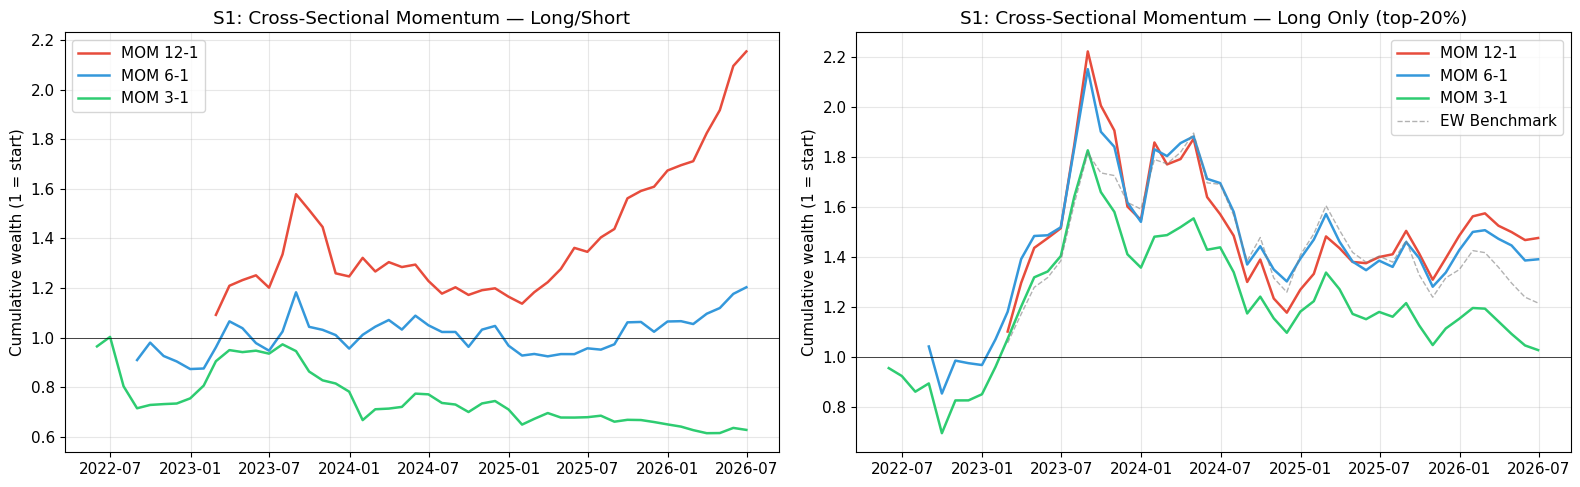

In [52]:

# S1  Equity curves

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {'MOM 12-1': '#e74c3c', 'MOM 6-1': '#3498db', 'MOM 3-1': '#2ecc71'}

for label, bt in s1_results.items():
    c = colors[label]
    cum_ls = (1 + bt['ls']).cumprod()
    cum_lo = (1 + bt['long_only']).cumprod()
    axes[0].plot(cum_ls.index, cum_ls, label=label, color=c, linewidth=1.8)
    axes[1].plot(cum_lo.index, cum_lo, label=label, color=c, linewidth=1.8)

# Benchmark on long-only chart
cum_ew = (1 + ew_benchmark.loc[s1_results['MOM 12-1']['ls'].index]).cumprod()
axes[1].plot(cum_ew.index, cum_ew, label='EW Benchmark', color='grey',
             linewidth=1, alpha=0.6, linestyle='--')

axes[0].set_title('S1: Cross-Sectional Momentum -- Long/Short')
axes[1].set_title('S1: Cross-Sectional Momentum -- Long Only (top-20%)')
for ax in axes:
    ax.axhline(1, color='black', linewidth=0.5)
    ax.set_ylabel('Cumulative wealth (1 = start)')
    ax.legend()

plt.tight_layout()
plt.show()

---

# S2: Time Series Momentum (TSMOM)

**Moskowitz, Ooi & Pedersen (2012), *Journal of Financial Economics***

Key differences from cross-sectional: each stock is traded independently based on the sign of its own past return. Position is scaled inversely by realized volatility (target vol = 40% ann.).

In [53]:

# S2  Time Series Momentum (TSMOM)

def tsmom_backtest(monthly_prices, monthly_ret, lookback=12, skip=1,
                   vol_window=12, target_vol=0.10, min_stocks=20,
                   cost_rt=COST_RT):
    """
    Time-series momentum following Moskowitz, Ooi & Pedersen (2012).
    
    Each stock gets +1 or -1 position based on sign of its own past return,
    scaled inversely by its realized volatility.
    
    Returns monthly portfolio return series.
    """
    # Past return signal (lookback with skip)
    past_ret = monthly_prices.shift(skip) / monthly_prices.shift(lookback) - 1
    
    # Rolling realized volatility (annualized from monthly)
    rolling_vol = monthly_ret.rolling(vol_window).std() * np.sqrt(12)
    
    port_rets = []
    dates = []
    positions_count = []
    
    for i in range(max(lookback, vol_window), len(monthly_ret) - 1):
        sig = past_ret.iloc[i].dropna()
        vol = rolling_vol.iloc[i].dropna()
        next_r = monthly_ret.iloc[i + 1]
        
        # Common tickers with signal, vol, and future return
        common = sig.index.intersection(vol.index).intersection(next_r.dropna().index)
        # Filter out zero/tiny vol
        common = [t for t in common if vol[t] > 0.05]
        
        if len(common) < min_stocks:
            continue
        
        # Position: sign(past return) / vol, normalized
        signs = np.sign(sig[common])
        inv_vol = 1.0 / vol[common]
        
        # Raw weights (unnormalized)
        raw_w = signs * inv_vol
        
        # Normalize to target vol: scale so that sum(|w|) * avg_vol ≈ target
        # Simpler: equal risk contribution with sign
        w = raw_w / raw_w.abs().sum() * target_vol / (vol[common].mean())
        
        # Cap individual weight at 10%
        w = w.clip(-0.10, 0.10)
        # Renormalize
        w = w / w.abs().sum()
        
        # Portfolio return
        r = (w * next_r[common]).sum()
        
        # Transaction costs: estimate turnover
        # For simplicity assume ~50% monthly turnover (conservative)
        r -= cost_rt * 0.5
        
        port_rets.append(r)
        dates.append(monthly_ret.index[i + 1])
        positions_count.append(len(common))
    
    return pd.Series(port_rets, index=pd.DatetimeIndex(dates), name='TSMOM'), \
           pd.Series(positions_count, index=pd.DatetimeIndex(dates), name='N_pos')


# Long-only variant: only take positive signals
def tsmom_longonly_backtest(monthly_prices, monthly_ret, lookback=12, skip=1,
                            vol_window=12, min_stocks=10, cost_rt=COST_RT):
    """
    TSMOM long-only: buy stocks with positive past return,
    weight inversely by volatility.
    """
    past_ret = monthly_prices.shift(skip) / monthly_prices.shift(lookback) - 1
    rolling_vol = monthly_ret.rolling(vol_window).std() * np.sqrt(12)
    
    port_rets = []
    dates = []
    
    for i in range(max(lookback, vol_window), len(monthly_ret) - 1):
        sig = past_ret.iloc[i].dropna()
        vol = rolling_vol.iloc[i].dropna()
        next_r = monthly_ret.iloc[i + 1]
        
        common = sig.index.intersection(vol.index).intersection(next_r.dropna().index)
        common = [t for t in common if vol[t] > 0.05]
        
        # Only positive signals
        pos_tickers = [t for t in common if sig[t] > 0]
        
        if len(pos_tickers) < min_stocks:
            # If too few positive, go to cash (return = 0 approx)
            port_rets.append(-cost_rt * 0.1)  # minimal cost
            dates.append(monthly_ret.index[i + 1])
            continue
        
        # Weight inversely by vol
        inv_vol = 1.0 / vol[pos_tickers]
        w = inv_vol / inv_vol.sum()  # sum to 1
        
        r = (w * next_r[pos_tickers]).sum() - cost_rt * 0.3  # ~30% turnover
        
        port_rets.append(r)
        dates.append(monthly_ret.index[i + 1])
    
    return pd.Series(port_rets, index=pd.DatetimeIndex(dates), name='TSMOM_LO')


# Run TSMOM variants
s2_results = {}
s2_metrics = []

for lb, sk, label in [(12, 1, 'TSMOM 12-1'), (6, 1, 'TSMOM 6-1'), (3, 1, 'TSMOM 3-1')]:
    ts_ret, ts_n = tsmom_backtest(monthly_close, monthly_ret,
                                   lookback=lb, skip=sk)
    ts_lo = tsmom_longonly_backtest(monthly_close, monthly_ret,
                                    lookback=lb, skip=sk)
    s2_results[label] = {'ls': ts_ret, 'long_only': ts_lo, 'n_pos': ts_n}
    
    m = portfolio_metrics(ts_ret, name=f'{label} L/S')
    m_lo = portfolio_metrics(ts_lo, name=f'{label} Long')
    if m: s2_metrics.append(m)
    if m_lo: s2_metrics.append(m_lo)

print('S2: Time Series Momentum (Moskowitz, Ooi & Pedersen 2012)')
print('=' * 80)
display(format_metrics_table(s2_metrics))

S2: Time Series Momentum (Moskowitz, Ooi & Pedersen 2012)


,N months,Ann.Ret%,Ann.Vol%,Sharpe,Sortino,MaxDD%,Calmar,t-stat,p-val,Win%
Strategy,,,,,,,,,,
TSMOM 12-1 L/S,41,12.7,13.6,-0.22,-0.26,17.8,0.71,1.62,0.112,56
TSMOM 12-1 Long,41,20.8,22.8,0.18,0.22,33.5,0.62,1.55,0.129,54
TSMOM 6-1 L/S,41,9.8,15.1,-0.37,-0.43,21.5,0.46,1.15,0.256,51
TSMOM 6-1 Long,41,15.5,20.6,-0.02,-0.03,27.9,0.56,1.31,0.199,44
TSMOM 3-1 L/S,41,9.2,14.6,-0.42,-0.47,26.7,0.35,1.13,0.266,54
TSMOM 3-1 Long,41,13.1,20.7,-0.12,-0.15,26.8,0.49,1.11,0.273,44


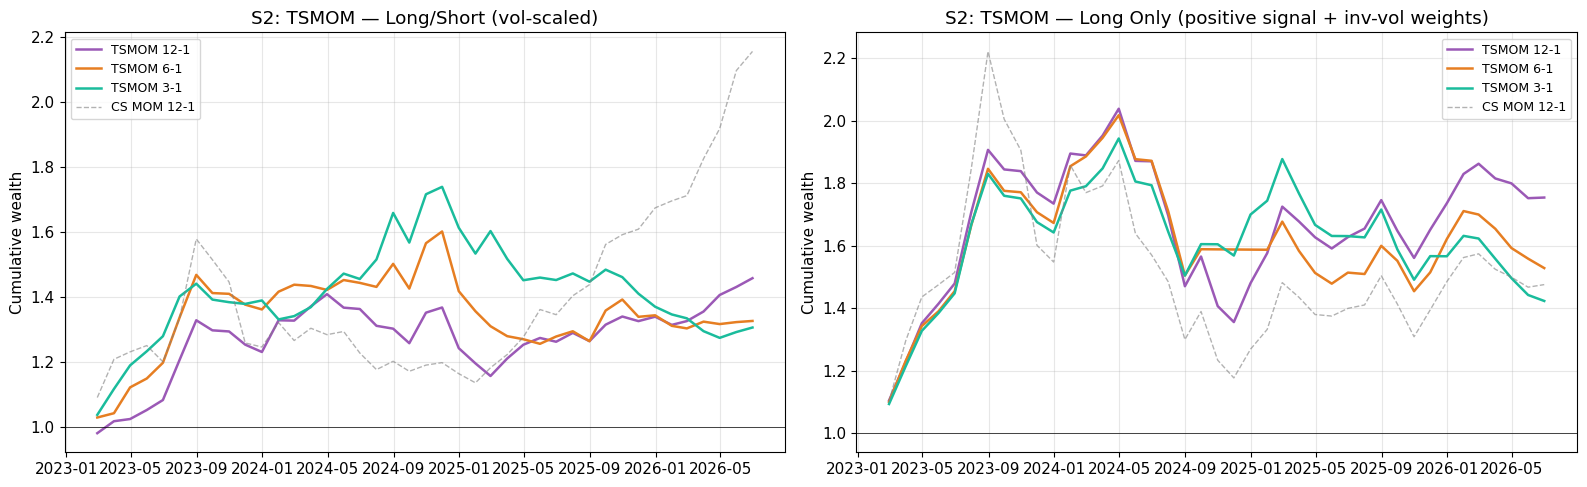

TSMOM 12-1: avg 101 positions/month, min 99, max 103
TSMOM 6-1: avg 101 positions/month, min 99, max 103
TSMOM 3-1: avg 101 positions/month, min 99, max 103


In [54]:
# TSMOM equity curves

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors2 = {'TSMOM 12-1': '#9b59b6', 'TSMOM 6-1': '#e67e22', 'TSMOM 3-1': '#1abc9c'}

for label, bt in s2_results.items():
    c = colors2[label]
    cum_ls = (1 + bt['ls']).cumprod()
    cum_lo = (1 + bt['long_only']).cumprod()
    axes[0].plot(cum_ls.index, cum_ls, label=label, color=c, linewidth=1.8)
    axes[1].plot(cum_lo.index, cum_lo, label=label, color=c, linewidth=1.8)

# Add CS momentum baseline for comparison
if 'MOM 12-1' in s1_results:
    cum_cs = (1 + s1_results['MOM 12-1']['ls']).cumprod()
    axes[0].plot(cum_cs.index, cum_cs, label='CS MOM 12-1', color='grey',
                 linewidth=1, linestyle='--', alpha=0.6)
    cum_cs_lo = (1 + s1_results['MOM 12-1']['long_only']).cumprod()
    axes[1].plot(cum_cs_lo.index, cum_cs_lo, label='CS MOM 12-1', color='grey',
                 linewidth=1, linestyle='--', alpha=0.6)

axes[0].set_title('S2: TSMOM -- Long/Short (vol-scaled)')
axes[1].set_title('S2: TSMOM -- Long Only (positive signal + inv-vol weights)')
for ax in axes:
    ax.axhline(1, color='black', linewidth=0.5)
    ax.set_ylabel('Cumulative wealth')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Show average number of positions
for label, bt in s2_results.items():
    print(f"{label}: avg {bt['n_pos'].mean():.0f} positions/month, "
          f"min {bt['n_pos'].min()}, max {bt['n_pos'].max()}")

---

# S3: Frog in the Pan -- Information Discreteness

**Da, Gurun & Warachka (2014), *Review of Financial Studies***

Hypothesis: investors underreact to information arriving in small increments. Momentum is stronger for stocks whose price move accumulated through many small daily returns (continuous) rather than a few large ones (discrete). Signal: combine past return with information discreteness (ID).

In [55]:

# S3  Frog in the Pan: compute ID from daily returns

def compute_id_signal(daily_close, monthly_index, lookback_months=12, skip_months=1):
    """
    Compute Information Discreteness (ID) for each stock at each month-end.
    
    ID = sign(PRET) × (%neg − %pos)
    
    where %pos/%neg = fraction of positive/negative daily returns
    during the formation period (t-lookback to t-skip).
    
    Returns: DataFrame of ID values (index=monthly dates, columns=tickers)
    """
    tickers = daily_close.columns
    daily_ret_local = daily_close.pct_change()
    
    id_records = []
    
    for mi in range(lookback_months, len(monthly_index)):
        month_end = monthly_index[mi]
        
        # Formation period boundaries
        # t-skip month end
        if skip_months > 0 and mi - skip_months >= 0:
            form_end = monthly_index[mi - skip_months]
        else:
            form_end = month_end
        
        # t-lookback month end
        if mi - lookback_months >= 0:
            form_start = monthly_index[mi - lookback_months]
        else:
            continue
        
        # Daily returns in formation period
        mask = (daily_ret_local.index > form_start) & (daily_ret_local.index <= form_end)
        period_rets = daily_ret_local.loc[mask]
        
        if len(period_rets) < 20:  # need enough days
            continue
        
        row = {}
        for ticker in tickers:
            tr = period_rets[ticker].dropna()
            if len(tr) < 20:
                continue
            
            # PRET: cumulative return over formation period
            pret = (1 + tr).prod() - 1
            if pret == 0:
                continue
            
            pct_pos = (tr > 0).mean()
            pct_neg = (tr < 0).mean()
            
            id_val = np.sign(pret) * (pct_neg - pct_pos)
            row[ticker] = id_val
        
        if row:
            id_records.append({'date': month_end, **row})
    
    id_df = pd.DataFrame(id_records).set_index('date')
    id_df.index = pd.DatetimeIndex(id_df.index)
    return id_df


print('Computing ID signals from daily data...')
id_12 = compute_id_signal(daily_close, monthly_close.index, lookback_months=12, skip_months=1)
print(f'ID signal computed: {id_12.shape[0]} months × {id_12.shape[1]} tickers')
print(f'\nID distribution:')
print(id_12.stack().describe().round(3))

Computing ID signals from daily data...
ID signal computed: 42 months × 109 tickers

ID distribution:
count    4440.000
mean       -0.040
std         0.074
min        -0.458
25%        -0.087
50%        -0.039
75%         0.007
max         0.385
dtype: float64


In [56]:

# S3 FIP double-sort backtest

def fip_double_sort_backtest(monthly_prices, monthly_ret, id_df,
                              lookback=12, skip=1, n_mom_groups=3,
                              n_id_groups=3, min_stocks=30, cost_rt=COST_RT):
    """
    Double-sort: first by PRET (momentum), then by ID.
    
    Following Da, Gurun & Warachka (2014):
    - Sort into n_mom_groups by PRET
    - Within each mom group, sort by ID
    - Compare: low-ID winners (continuous) vs high-ID winners (discrete)
    
    Returns dict of monthly return series for different portfolios.
    """
    pret = monthly_prices.shift(skip) / monthly_prices.shift(lookback) - 1
    
    results = {key: [] for key in [
        'winner_cont', 'winner_disc',  # Winners: continuous vs discrete
        'loser_cont', 'loser_disc',    # Losers: continuous vs discrete
        'enhanced_ls',                  # Enhanced: long winner+continuous, short loser+continuous
        'plain_ls',                     # Plain: long all winners, short all losers
    ]}
    dates = []
    
    common_months = pret.index.intersection(id_df.index)
    
    for month in common_months:
        p = pret.loc[month].dropna()
        id_row = id_df.loc[month].dropna() if month in id_df.index else pd.Series(dtype=float)
        
        if id_row.empty:
            continue
        
        common = p.index.intersection(id_row.index)
        
        # Next month return
        month_loc = monthly_ret.index.get_loc(month)
        if month_loc + 1 >= len(monthly_ret):
            continue
        next_month = monthly_ret.index[month_loc + 1]
        next_r = monthly_ret.loc[next_month]
        
        common = common.intersection(next_r.dropna().index)
        if len(common) < min_stocks:
            continue
        
        p_c = p[common]
        id_c = id_row[common]
        r_c = next_r[common]
        
        # Sort by momentum into groups
        try:
            mom_q = pd.qcut(p_c, n_mom_groups, labels=False, duplicates='drop')
        except ValueError:
            continue
        
        winners = mom_q[mom_q == n_mom_groups - 1].index
        losers  = mom_q[mom_q == 0].index
        
        if len(winners) < 6 or len(losers) < 6:
            continue
        
        # Within winners: sort by ID
        id_winners = id_c[winners]
        id_med_w = id_winners.median()
        w_cont = id_winners[id_winners <= id_med_w].index  # low ID = continuous
        w_disc = id_winners[id_winners > id_med_w].index   # high ID = discrete
        
        # Within losers: sort by ID
        id_losers = id_c[losers]
        id_med_l = id_losers.median()
        l_cont = id_losers[id_losers <= id_med_l].index
        l_disc = id_losers[id_losers > id_med_l].index
        
        dates.append(next_month)
        
        results['winner_cont'].append(r_c[w_cont].mean() if len(w_cont) > 0 else np.nan)
        results['winner_disc'].append(r_c[w_disc].mean() if len(w_disc) > 0 else np.nan)
        results['loser_cont'].append(r_c[l_cont].mean() if len(l_cont) > 0 else np.nan)
        results['loser_disc'].append(r_c[l_disc].mean() if len(l_disc) > 0 else np.nan)
        
        # Enhanced L/S: long continuous winners, short continuous losers
        long_r  = r_c[w_cont].mean() if len(w_cont) > 0 else 0
        short_r = r_c[l_cont].mean() if len(l_cont) > 0 else 0
        results['enhanced_ls'].append(long_r - short_r - cost_rt)
        
        # Plain L/S: all winners vs all losers
        results['plain_ls'].append(r_c[winners].mean() - r_c[losers].mean() - cost_rt)
    
    idx = pd.DatetimeIndex(dates)
    return {k: pd.Series(v, index=idx) for k, v in results.items()}


# Enhanced momentum: use ID as additional ranking signal
def fip_enhanced_backtest(monthly_prices, monthly_ret, id_df,
                           lookback=12, skip=1, top_pct=0.20,
                           id_weight=0.5, cost_rt=COST_RT):
    """
    Enhanced momentum: combine PRET rank with (-ID) rank.
    score = (1 - id_weight) * mom_rank + id_weight * (-id_rank)
    
    Low ID = continuous info → high -ID rank → gets boosted.
    """
    pret = monthly_prices.shift(skip) / monthly_prices.shift(lookback) - 1
    common_months = pret.index.intersection(id_df.index)
    
    long_rets = []
    ls_rets = []
    dates = []
    
    for month in common_months:
        p = pret.loc[month].dropna()
        id_row = id_df.loc[month].dropna()
        
        common = p.index.intersection(id_row.index)
        
        month_loc = monthly_ret.index.get_loc(month)
        if month_loc + 1 >= len(monthly_ret):
            continue
        next_month = monthly_ret.index[month_loc + 1]
        next_r = monthly_ret.loc[next_month]
        common = common.intersection(next_r.dropna().index)
        
        if len(common) < 20:
            continue
        
        # Composite score
        mom_rank = p[common].rank(pct=True)       # high = winner
        id_rank  = (-id_row[common]).rank(pct=True) # high = continuous (low ID)
        
        score = (1 - id_weight) * mom_rank + id_weight * id_rank
        
        n_pick = max(1, int(len(common) * top_pct))
        longs  = score.nlargest(n_pick).index
        shorts = score.nsmallest(n_pick).index
        
        r_long = next_r[longs].mean() - cost_rt / 2
        r_ls   = r_long + (-next_r[shorts].mean() - cost_rt / 2)
        
        long_rets.append(r_long)
        ls_rets.append(r_ls)
        dates.append(next_month)
    
    idx = pd.DatetimeIndex(dates)
    return {
        'long_only': pd.Series(long_rets, index=idx),
        'ls': pd.Series(ls_rets, index=idx),
    }


# Run double-sort
print('Running FIP double-sort backtest...')
fip_ds = fip_double_sort_backtest(monthly_close, monthly_ret, id_12)

# Run enhanced with different ID weights
s3_results = {}
s3_metrics = []

# Plain momentum (no ID) as baseline
fip_plain = fip_enhanced_backtest(monthly_close, monthly_ret, id_12,
                                   id_weight=0.0)
m = portfolio_metrics(fip_plain['ls'], name='S1 MOM 12-1 (no ID)')
if m: s3_metrics.append(m)
s3_results['No ID (w=0.0)'] = fip_plain

# Enhanced with ID
for w in [0.25, 0.50, 0.75]:
    bt = fip_enhanced_backtest(monthly_close, monthly_ret, id_12,
                                id_weight=w)
    label_ls = f'MOM+ID w={w:.2f} L/S'
    label_lo = f'MOM+ID w={w:.2f} Long'
    m_ls = portfolio_metrics(bt['ls'], name=label_ls)
    m_lo = portfolio_metrics(bt['long_only'], name=label_lo)
    if m_ls: s3_metrics.append(m_ls)
    if m_lo: s3_metrics.append(m_lo)
    s3_results[f'ID w={w:.2f}'] = bt

# Double-sort results
m_enh = portfolio_metrics(fip_ds['enhanced_ls'], name='FIP Enhanced L/S')
m_pln = portfolio_metrics(fip_ds['plain_ls'], name='FIP Plain L/S')
if m_enh: s3_metrics.append(m_enh)
if m_pln: s3_metrics.append(m_pln)

print('\nS3: Frog in the Pan (Da, Gurun & Warachka 2014)')
print('=' * 80)
display(format_metrics_table(s3_metrics))

Running FIP double-sort backtest...

S3: Frog in the Pan (Da, Gurun & Warachka 2014)


,N months,Ann.Ret%,Ann.Vol%,Sharpe,Sortino,MaxDD%,Calmar,t-stat,p-val,Win%
Strategy,,,,,,,,,,
S1 MOM 12-1 (no ID),41,27.4,19.2,0.49,0.64,28.0,0.98,2.35**,0.024,68
MOM+ID w=0.25 L/S,41,29.8,16.8,0.68,1.00,15.4,1.93,2.90***,0.006,66
MOM+ID w=0.25 Long,41,19.8,29.9,0.11,0.16,40.2,0.49,1.13,0.267,51
MOM+ID w=0.50 L/S,41,13.7,10.7,-0.19,-0.19,12.4,1.10,2.23**,0.032,66
MOM+ID w=0.50 Long,41,15.2,25.2,-0.03,-0.04,35.7,0.43,1.05,0.302,49
MOM+ID w=0.75 L/S,41,0.2,10.5,-1.40,-1.22,14.5,0.01,0.04,0.971,49
MOM+ID w=0.75 Long,41,11.4,25.5,-0.16,-0.19,34.0,0.33,0.79,0.437,51
FIP Enhanced L/S,41,20.4,17.5,0.22,0.31,25.7,0.79,1.98*,0.054,63
FIP Plain L/S,41,20.5,14.4,0.27,0.40,16.8,1.22,2.42**,0.020,59


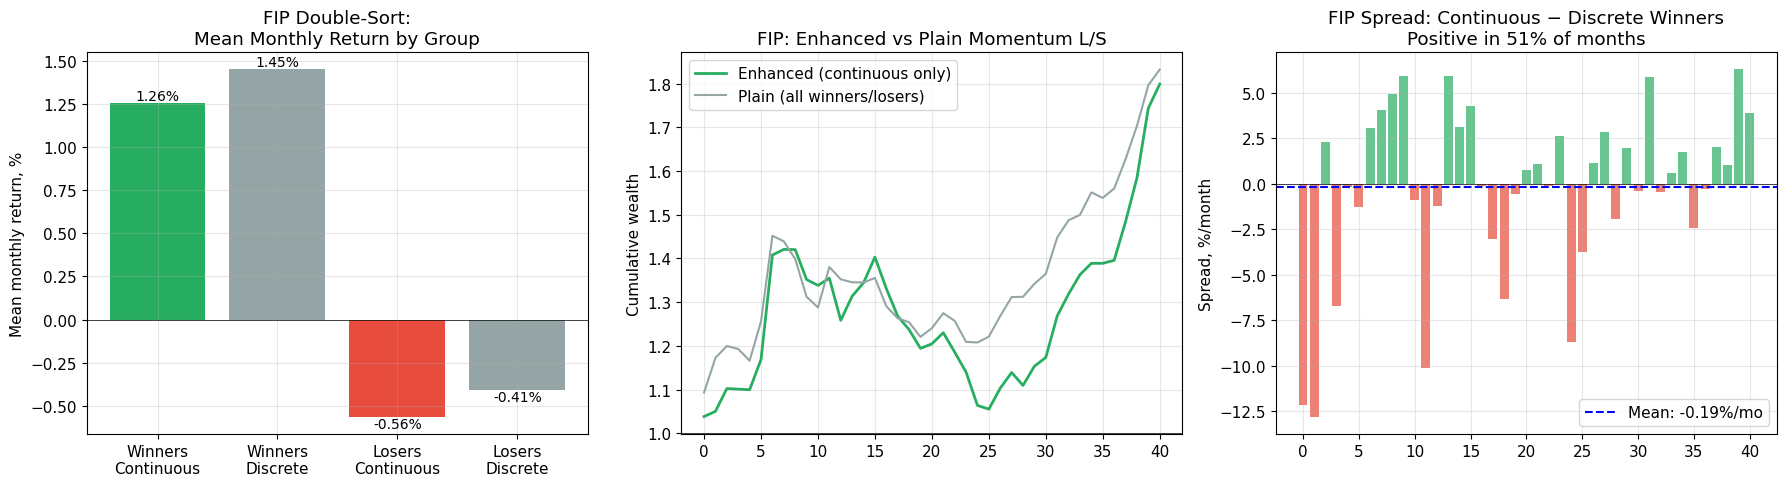


FIP Spread (continuous − discrete winners):
  Mean: -0.19%/month
  t-stat: -0.26, p-value: 0.794
  → НЕ значим на 5% уровне


In [57]:

# S3  FIP double-sort analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Winner portfolios: continuous vs discrete
wc = pd.Series(fip_ds['winner_cont']).dropna()
wd = pd.Series(fip_ds['winner_disc']).dropna()
lc = pd.Series(fip_ds['loser_cont']).dropna()
ld = pd.Series(fip_ds['loser_disc']).dropna()

labels = ['Winners\nContinuous', 'Winners\nDiscrete',
          'Losers\nContinuous', 'Losers\nDiscrete']
means = [wc.mean()*100, wd.mean()*100, lc.mean()*100, ld.mean()*100]
colors_bar = ['#27ae60', '#95a5a6', '#e74c3c', '#95a5a6']

bars = axes[0].bar(labels, means, color=colors_bar)
axes[0].axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, val,
                 f'{val:.2f}%', ha='center',
                 va='bottom' if val >= 0 else 'top', fontsize=10)
axes[0].set_title('FIP Double-Sort:\nMean Monthly Return by Group')
axes[0].set_ylabel('Mean monthly return, %')

# 2. Enhanced vs plain L/S equity curves
cum_enh = (1 + pd.Series(fip_ds['enhanced_ls'])).cumprod()
cum_pln = (1 + pd.Series(fip_ds['plain_ls'])).cumprod()
axes[1].plot(cum_enh.values, label='Enhanced (continuous only)', color='#27ae60', linewidth=2)
axes[1].plot(cum_pln.values, label='Plain (all winners/losers)', color='#95a5a6', linewidth=1.5)
axes[1].axhline(1, color='black', linewidth=0.5)
axes[1].set_title('FIP: Enhanced vs Plain Momentum L/S')
axes[1].set_ylabel('Cumulative wealth')
axes[1].legend()

# 3. FIP Spread: winner_cont − winner_disc
fip_spread = (wc.values - wd.values) * 100
pos_mask = fip_spread > 0
axes[2].bar(range(len(fip_spread)), fip_spread,
            color=['#27ae60' if p else '#e74c3c' for p in pos_mask], alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].axhline(fip_spread.mean(), color='blue', linestyle='--',
                label=f'Mean: {fip_spread.mean():.2f}%/mo')
win_pct = pos_mask.mean() * 100
axes[2].set_title(f'FIP Spread: Continuous − Discrete Winners\n'
                   f'Positive in {win_pct:.0f}% of months')
axes[2].set_ylabel('Spread, %/month')
axes[2].legend()

plt.tight_layout()
plt.show()

# t-test on FIP spread
t_fip, p_fip = stats.ttest_1samp(fip_spread, 0)
print(f'\nFIP Spread (continuous − discrete winners):')
print(f'  Mean: {fip_spread.mean():.2f}%/month')
print(f'  t-stat: {t_fip:.2f}, p-value: {p_fip:.3f}')
print(f'  → {"ЗНАЧИМ" if p_fip < 0.05 else "НЕ значим"} на 5% уровне')

---

# S4: GLM Momentum

**Saejoon Kim (2020), *Finance Research Letters***

Instead of a single lookback horizon (12-1), a regularized linear model combines multiple past returns (1m, 3m, 6m, 12m) to predict future return. Models: Lasso, Ridge, ElasticNet  trained in an expanding window.

In [58]:

# S4  GLM Momentum: feature engineering

def build_glm_features(monthly_prices, monthly_ret):
    """
    Build feature matrix for GLM momentum.
    
    Features (for each stock at each month):
    - MOM_1:  return over past 1 month (t-1 to t)
    - MOM_3:  return over t-3 to t-1  (skip 1)
    - MOM_6:  return over t-6 to t-1  (skip 1)
    - MOM_12: return over t-12 to t-1 (skip 1)
    - VOL_3:  realized vol over last 3 months
    - VOL_12: realized vol over last 12 months
    
    Target: return in month t+1
    """
    features = {}
    
    # Momentum features
    features['MOM_1']  = monthly_ret.shift(0)  # most recent month return (no skip)
    features['MOM_3']  = monthly_prices.shift(1) / monthly_prices.shift(3) - 1
    features['MOM_6']  = monthly_prices.shift(1) / monthly_prices.shift(6) - 1
    features['MOM_12'] = monthly_prices.shift(1) / monthly_prices.shift(12) - 1
    
    # Volatility features
    features['VOL_3']  = monthly_ret.rolling(3).std()
    features['VOL_12'] = monthly_ret.rolling(12).std()
    
    # Target: next month return
    target = monthly_ret.shift(-1)  # forward return
    
    return features, target


def prepare_panel(features, target, month_idx):
    """
    For a given month, create cross-sectional panel:
    rows = stocks, columns = features, y = target return.
    """
    rows = []
    tickers = []
    for ticker in target.columns:
        y = target.iloc[month_idx].get(ticker, np.nan)
        if pd.isna(y):
            continue
        feat_vals = {}
        all_valid = True
        for fname, fdf in features.items():
            val = fdf.iloc[month_idx].get(ticker, np.nan)
            if pd.isna(val) or np.isinf(val):
                all_valid = False
                break
            feat_vals[fname] = val
        if all_valid:
            feat_vals['y'] = y
            rows.append(feat_vals)
            tickers.append(ticker)
    
    if not rows:
        return None, None, None
    
    df = pd.DataFrame(rows, index=tickers)
    X = df.drop('y', axis=1)
    y = df['y']
    return X, y, tickers


features, target = build_glm_features(monthly_close, monthly_ret)
print('Features built:')
for fname in features:
    non_null = features[fname].count().mean()
    print(f'  {fname:10s}: avg {non_null:.0f} non-null values/month')
print(f'\nTarget (next month return): {target.shape}')

Features built:
  MOM_1     : avg 50 non-null values/month
  MOM_3     : avg 48 non-null values/month
  MOM_6     : avg 45 non-null values/month
  MOM_12    : avg 39 non-null values/month
  VOL_3     : avg 48 non-null values/month
  VOL_12    : avg 39 non-null values/month

Target (next month return): (54, 109)


In [59]:

# S4  GLM expanding-window backtest

def glm_momentum_backtest(features, target, monthly_ret,
                           min_train_months=18, top_pct=0.20,
                           model_type='lasso', cost_rt=COST_RT):
    """
    GLM Momentum with strict expanding-window cross-validation.
    
    For each month t:
    1. Train model on months [0..t-1] (all past data)
    2. Predict cross-sectional returns at month t
    3. Long top predicted, short bottom predicted
    
    No look-ahead bias: model only sees past data.
    """
    T = len(monthly_ret)
    
    long_rets = []
    ls_rets = []
    dates = []
    coefs_history = []
    
    scaler = StandardScaler()
    
    for t in range(min_train_months, T - 1):
        # --- Accumulate training data (all months < t) ---
        X_train_parts = []
        y_train_parts = []
        
        for m in range(12, t):  # start from 12 to have features
            X_m, y_m, _ = prepare_panel(features, target, m)
            if X_m is not None and len(X_m) >= 15:
                X_train_parts.append(X_m)
                y_train_parts.append(y_m)
        
        if len(X_train_parts) < min_train_months - 12:
            continue
        
        X_train = pd.concat(X_train_parts)
        y_train = pd.concat(y_train_parts)
        
        # Remove outliers (winsorize at 1%/99%)
        for col in X_train.columns:
            lo, hi = X_train[col].quantile([0.01, 0.99])
            X_train[col] = X_train[col].clip(lo, hi)
        y_lo, y_hi = y_train.quantile([0.01, 0.99])
        y_train = y_train.clip(y_lo, y_hi)
        
        # --- Fit model ---
        X_sc = scaler.fit_transform(X_train)
        
        try:
            if model_type == 'lasso':
                model = LassoCV(cv=5, max_iter=5000, random_state=42)
            elif model_type == 'ridge':
                model = RidgeCV(cv=5)
            elif model_type == 'elasticnet':
                model = ElasticNetCV(cv=5, max_iter=5000, random_state=42,
                                     l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9])
            else:
                raise ValueError(f'Unknown model: {model_type}')
            
            model.fit(X_sc, y_train)
        except Exception as e:
            continue
        
        # --- Predict at month t ---
        X_test, _, tickers_test = prepare_panel(features, target, t)
        if X_test is None or len(X_test) < 15:
            continue
        
        # Clip test features same way
        for col in X_test.columns:
            lo, hi = X_train[col].quantile([0.01, 0.99])
            X_test[col] = X_test[col].clip(lo, hi)
        
        X_test_sc = scaler.transform(X_test)
        y_pred = model.predict(X_test_sc)
        
        pred_series = pd.Series(y_pred, index=tickers_test)
        
        # --- Portfolio construction ---
        n_pick = max(1, int(len(pred_series) * top_pct))
        longs  = pred_series.nlargest(n_pick).index
        shorts = pred_series.nsmallest(n_pick).index
        
        # Actual next-month return (t+1)
        actual_next = monthly_ret.iloc[t + 1]
        
        r_long = actual_next[longs].dropna().mean() - cost_rt / 2
        r_short = actual_next[shorts].dropna().mean()
        r_ls = r_long + (-r_short - cost_rt / 2)
        
        long_rets.append(r_long)
        ls_rets.append(r_ls)
        dates.append(monthly_ret.index[t + 1])
        
        # Save coefficients
        coefs_history.append({
            'date': monthly_ret.index[t + 1],
            **dict(zip(X_train.columns, model.coef_))
        })
    
    idx = pd.DatetimeIndex(dates)
    coef_df = pd.DataFrame(coefs_history).set_index('date') if coefs_history else pd.DataFrame()
    
    return {
        'long_only': pd.Series(long_rets, index=idx),
        'ls': pd.Series(ls_rets, index=idx),
        'coefs': coef_df,
    }


# Run for all three model types
s4_results = {}
s4_metrics = []

for model_type in ['lasso', 'ridge', 'elasticnet']:
    print(f'Running GLM ({model_type})...')
    bt = glm_momentum_backtest(features, target, monthly_ret,
                                model_type=model_type)
    s4_results[model_type] = bt
    
    m_ls = portfolio_metrics(bt['ls'], name=f'GLM {model_type.title()} L/S')
    m_lo = portfolio_metrics(bt['long_only'], name=f'GLM {model_type.title()} Long')
    if m_ls: s4_metrics.append(m_ls)
    if m_lo: s4_metrics.append(m_lo)

print('\nS4: GLM Momentum (Kim 2020)')
print('=' * 80)
display(format_metrics_table(s4_metrics))

Running GLM (lasso)...
Running GLM (ridge)...
Running GLM (elasticnet)...

S4: GLM Momentum (Kim 2020)


,N months,Ann.Ret%,Ann.Vol%,Sharpe,Sortino,MaxDD%,Calmar,t-stat,p-val,Win%
Strategy,,,,,,,,,,
GLM Lasso L/S,35,-12.2,14.5,-1.91,-1.63,34.4,-0.35,-1.51,0.139,26
GLM Lasso Long,35,-16.1,21.0,-1.54,-1.29,48.5,-0.33,-1.41,0.167,34
GLM Ridge L/S,35,3.8,25.2,-0.44,-0.60,34.6,0.11,0.26,0.800,46
GLM Ridge Long,35,-4.3,27.6,-0.70,-0.88,42.2,-0.10,-0.27,0.788,34
GLM Elasticnet L/S,35,-12.2,14.5,-1.91,-1.63,34.4,-0.35,-1.51,0.139,26
GLM Elasticnet Long,35,-16.1,21.0,-1.54,-1.29,48.5,-0.33,-1.41,0.167,34


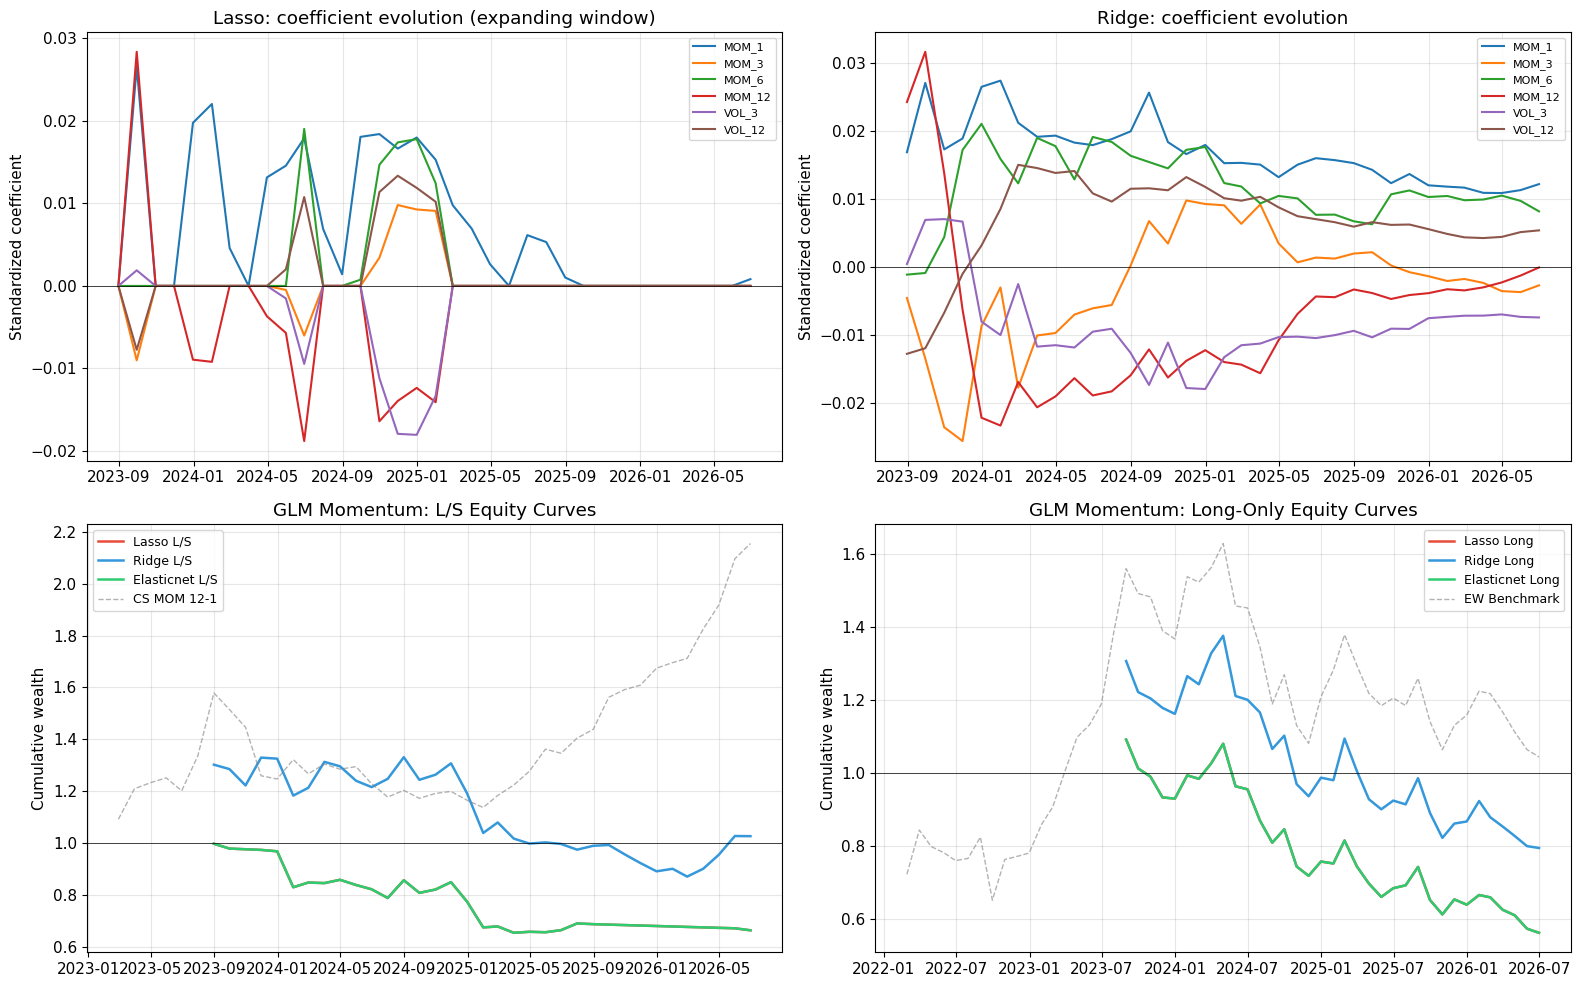


Lasso: avg coefficients (last 12 months):
  MOM_1     : +0.0006  +
  MOM_3     : +0.0000  -
  MOM_6     : +0.0000  -
  MOM_12    : +0.0000  -
  VOL_3     : +0.0000  -
  VOL_12    : +0.0000  -


In [60]:

# S4  GLM coefficient evolution & equity

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Lasso coefficients over time
ax = axes[0, 0]
if not s4_results['lasso']['coefs'].empty:
    coefs = s4_results['lasso']['coefs']
    for col in coefs.columns:
        ax.plot(coefs.index, coefs[col], label=col, linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title('Lasso: coefficient evolution (expanding window)')
    ax.set_ylabel('Standardized coefficient')
    ax.legend(fontsize=8)

# 2. Ridge coefficients over time
ax = axes[0, 1]
if not s4_results['ridge']['coefs'].empty:
    coefs = s4_results['ridge']['coefs']
    for col in coefs.columns:
        ax.plot(coefs.index, coefs[col], label=col, linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title('Ridge: coefficient evolution')
    ax.set_ylabel('Standardized coefficient')
    ax.legend(fontsize=8)

# 3. L/S equity curves: all GLM models
ax = axes[1, 0]
glm_colors = {'lasso': '#e74c3c', 'ridge': '#3498db', 'elasticnet': '#2ecc71'}
for model_type, bt in s4_results.items():
    cum = (1 + bt['ls']).cumprod()
    ax.plot(cum.index, cum, label=f'{model_type.title()} L/S',
            color=glm_colors[model_type], linewidth=1.8)

# Add CS MOM 12-1 as reference
if 'MOM 12-1' in s1_results:
    cum_ref = (1 + s1_results['MOM 12-1']['ls']).cumprod()
    ax.plot(cum_ref.index, cum_ref, label='CS MOM 12-1', color='grey',
            linewidth=1, linestyle='--', alpha=0.6)

ax.axhline(1, color='black', linewidth=0.5)
ax.set_title('GLM Momentum: L/S Equity Curves')
ax.set_ylabel('Cumulative wealth')
ax.legend(fontsize=9)

# 4. Long-only equity
ax = axes[1, 1]
for model_type, bt in s4_results.items():
    cum = (1 + bt['long_only']).cumprod()
    ax.plot(cum.index, cum, label=f'{model_type.title()} Long',
            color=glm_colors[model_type], linewidth=1.8)

cum_ew2 = (1 + ew_benchmark).cumprod()
ax.plot(cum_ew2.index, cum_ew2, label='EW Benchmark', color='grey',
        linewidth=1, linestyle='--', alpha=0.6)

ax.axhline(1, color='black', linewidth=0.5)
ax.set_title('GLM Momentum: Long-Only Equity Curves')
ax.set_ylabel('Cumulative wealth')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Average Lasso coefficients (last 12 months)
if not s4_results['lasso']['coefs'].empty:
    avg_coefs = s4_results['lasso']['coefs'].tail(12).mean().sort_values(ascending=False)
    print('\nLasso: avg coefficients (last 12 months):')
    for feat, val in avg_coefs.items():
        bar = '█' * int(abs(val) * 100)
        sign = '+' if val > 0 else '-'
        print(f'  {feat:10s}: {val:+.4f}  {sign}{bar}')

---

# S5: Residual Momentum

**Blitz, Huij & Martens (2011), *Journal of Empirical Finance***

Standard momentum signal is contaminated by market factor exposure. A stock may appear a winner simply because the market rose and it has high beta. Residual momentum purges market exposure by using CAPM residuals as the signal.

In [61]:

#  Residual Momentum  signal computation

def compute_residual_momentum(monthly_ret, market_ret, lookback=12, skip=1,
                               min_obs=8, method='regression'):
    """
    Residual momentum signal (Blitz, Huij & Martens 2011).
    
    For each stock at each month-end:
    1. Take monthly returns over formation period [t-lookback, t-skip]
    2. Regress on market factor (or demean)
    3. Cumulate residuals → residual return = signal
    
    method: 'regression' = OLS on market, 'demean' = subtract cross-sectional mean
    """
    signal = pd.DataFrame(index=monthly_ret.index, columns=monthly_ret.columns,
                          dtype=float)
    
    for i in range(lookback, len(monthly_ret)):
        # Formation period: [i-lookback, i-skip)
        start = i - lookback
        end   = i - skip if skip > 0 else i
        if end <= start:
            continue
        
        period_ret = monthly_ret.iloc[start:end]
        period_mkt = market_ret.iloc[start:end]
        
        for ticker in monthly_ret.columns:
            y = period_ret[ticker].dropna()
            if len(y) < min_obs:
                continue
            
            if method == 'regression':
                # Align with market
                common_idx = y.index.intersection(period_mkt.dropna().index)
                if len(common_idx) < min_obs:
                    continue
                y_c = y.loc[common_idx]
                x_c = period_mkt.loc[common_idx]
                
                # OLS: r_i = alpha + beta * r_m + eps
                try:
                    slope, intercept, _, _, _ = stats.linregress(x_c.values, y_c.values)
                    residuals = y_c.values - (intercept + slope * x_c.values)
                    # Residual return = sum of residuals (cumulative idiosyncratic return)
                    signal.at[signal.index[i], ticker] = residuals.sum()
                except:
                    continue
            
            elif method == 'demean':
                # Subtract cross-sectional mean each month
                cs_mean = period_ret.mean(axis=1)
                common_idx = y.index.intersection(cs_mean.dropna().index)
                if len(common_idx) < min_obs:
                    continue
                demeaned = y.loc[common_idx] - cs_mean.loc[common_idx]
                signal.at[signal.index[i], ticker] = demeaned.sum()
    
    return signal.astype(float)


# Compute both variants
print('Computing residual momentum signals...')

# Align IMOEX with monthly_ret
mkt = imoex_monthly.reindex(monthly_ret.index)

print('  1-factor (regression on IMOEX)...')
resid_signal_reg = compute_residual_momentum(monthly_ret, mkt,
                                              lookback=12, skip=1,
                                              method='regression')
n_reg = resid_signal_reg.count().sum()
print(f'    → {resid_signal_reg.dropna(how="all").shape[0]} months, '
      f'{n_reg} total signal values')

print('  Demeaned (cross-sectional)...')
resid_signal_dm = compute_residual_momentum(monthly_ret, mkt,
                                             lookback=12, skip=1,
                                             method='demean')
n_dm = resid_signal_dm.count().sum()
print(f'    → {resid_signal_dm.dropna(how="all").shape[0]} months, '
      f'{n_dm} total signal values')

# Compare with raw momentum signal
raw_signal = cs_momentum_signal(monthly_close, lookback=12, skip=1)

# Correlation between raw and residual signals (cross-sectional avg)
corrs_reg = []
corrs_dm = []
for i in range(len(monthly_ret)):
    raw = raw_signal.iloc[i].dropna()
    res_r = resid_signal_reg.iloc[i].dropna()
    res_d = resid_signal_dm.iloc[i].dropna()
    
    common_r = raw.index.intersection(res_r.index)
    common_d = raw.index.intersection(res_d.index)
    
    if len(common_r) > 10:
        corrs_reg.append(raw[common_r].corr(res_r[common_r]))
    if len(common_d) > 10:
        corrs_dm.append(raw[common_d].corr(res_d[common_d]))

print(f'\nCorrelation raw MOM vs residual MOM (avg cross-sectional):')
print(f'  1-factor:  {np.mean(corrs_reg):.3f}')
print(f'  Demeaned:  {np.mean(corrs_dm):.3f}')
print(f'  → Чем ниже, тем больше "нового" в residual сигнале')

Computing residual momentum signals...
  1-factor (regression on IMOEX)...
    → 42 months, 4347 total signal values
  Demeaned (cross-sectional)...
    → 42 months, 4347 total signal values

Correlation raw MOM vs residual MOM (avg cross-sectional):
  1-factor:  -0.020
  Demeaned:  0.878
  → Чем ниже, тем больше "нового" в residual сигнале


S5: Residual Momentum (Blitz, Huij & Martens 2011)


,N months,Ann.Ret%,Ann.Vol%,Sharpe,Sortino,MaxDD%,Calmar,t-stat,p-val,Win%
Strategy,,,,,,,,,,
CS MOM 12-1 L/S (ref),41,27.4,19.2,0.49,0.64,28.0,0.98,2.35**,0.024,68
ResMOM 1-factor L/S,41,3.2,13.1,-0.90,-0.99,22.8,0.14,0.44,0.663,49
ResMOM 1-factor Long,41,10.7,28.0,-0.17,-0.20,40.1,0.27,0.67,0.505,49
ResMOM Demeaned L/S,41,29.2,20.7,0.53,0.67,22.7,1.29,2.32**,0.026,68
ResMOM Demeaned Long,41,25.1,33.6,0.23,0.35,40.8,0.62,1.24,0.221,51


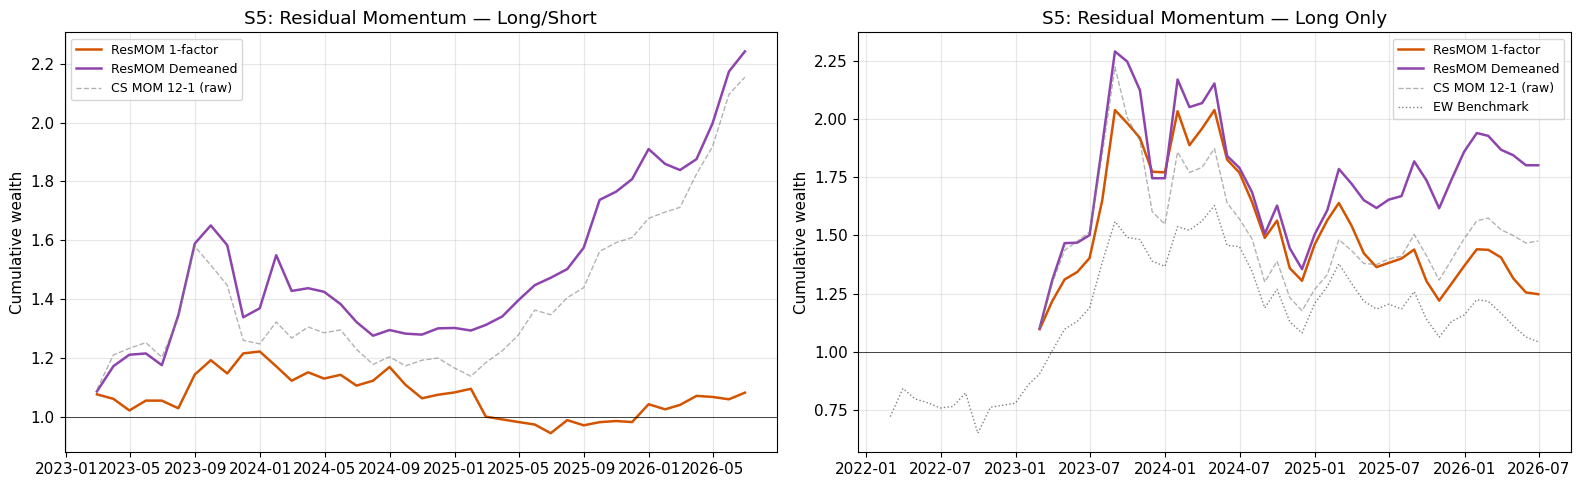


Alpha vs IMOEX:
  ResMOM 1-factor            α/mo=-0.20%  t=-0.17  p=0.862  IR=-0.09  β=-0.14
  ResMOM Demeaned            α/mo=+1.70%  t=1.49  p=0.145  IR=0.80  β=0.19

Correlation with other L/S strategies:
  ResMOM 1-factor:
    vs CS MOM 12-1    : 0.21
    vs TSMOM 12-1     : 0.05
    vs MOM+ID         : 0.13
  ResMOM Demeaned:
    vs CS MOM 12-1    : 0.89
    vs TSMOM 12-1     : 0.59
    vs MOM+ID         : 0.55


In [62]:

#Residual Momentum  backtest & comparison

# Backtest residual momentum using same engine as S1
s5_results = {}
s5_metrics = []

for label, sig_df in [('ResMOM 1-factor', resid_signal_reg),
                       ('ResMOM Demeaned', resid_signal_dm)]:
    bt = cs_momentum_backtest(sig_df, monthly_ret, top_pct=0.20)
    s5_results[label] = bt
    
    m_ls = portfolio_metrics(bt['ls'], name=f'{label} L/S')
    m_lo = portfolio_metrics(bt['long_only'], name=f'{label} Long')
    if m_ls: s5_metrics.append(m_ls)
    if m_lo: s5_metrics.append(m_lo)

# Add raw CS MOM 12-1 for direct comparison (same period)
if 'MOM 12-1' in s1_results:
    # Align to same period as residual
    ref_ls = s1_results['MOM 12-1']['ls']
    m_ref = portfolio_metrics(ref_ls, name='CS MOM 12-1 L/S (ref)')
    if m_ref: s5_metrics.insert(0, m_ref)

print('S5: Residual Momentum (Blitz, Huij & Martens 2011)')
print('=' * 80)
display(format_metrics_table(s5_metrics))

# --- Equity curves ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors5 = {'ResMOM 1-factor': '#d35400', 'ResMOM Demeaned': '#8e44ad'}

for label, bt in s5_results.items():
    c = colors5[label]
    cum_ls = (1 + bt['ls']).cumprod()
    cum_lo = (1 + bt['long_only']).cumprod()
    axes[0].plot(cum_ls.index, cum_ls, label=label, color=c, linewidth=1.8)
    axes[1].plot(cum_lo.index, cum_lo, label=label, color=c, linewidth=1.8)

# Add raw CS MOM as reference
if 'MOM 12-1' in s1_results:
    cum_ref = (1 + s1_results['MOM 12-1']['ls']).cumprod()
    axes[0].plot(cum_ref.index, cum_ref, label='CS MOM 12-1 (raw)',
                 color='grey', linewidth=1, linestyle='--', alpha=0.6)
    cum_ref_lo = (1 + s1_results['MOM 12-1']['long_only']).cumprod()
    axes[1].plot(cum_ref_lo.index, cum_ref_lo, label='CS MOM 12-1 (raw)',
                 color='grey', linewidth=1, linestyle='--', alpha=0.6)

# EW benchmark
cum_ew = (1 + ew_benchmark).cumprod()
axes[1].plot(cum_ew.index, cum_ew, label='EW Benchmark',
             color='black', linewidth=1, linestyle=':', alpha=0.5)

axes[0].set_title('S5: Residual Momentum -- Long/Short')
axes[1].set_title('S5: Residual Momentum -- Long Only')
for ax in axes:
    ax.axhline(1, color='black', linewidth=0.5)
    ax.set_ylabel('Cumulative wealth')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# --- Alpha test ---
print('\nAlpha vs IMOEX:')
for label, bt in s5_results.items():
    a = alpha_vs_benchmark(bt['ls'], imoex_monthly)
    if a:
        star = '***' if a['p_param'] < 0.01 else ('**' if a['p_param'] < 0.05 else ('*' if a['p_param'] < 0.1 else ''))
        print(f"  {label:25s}  α/mo={a['alpha_monthly']*100:+.2f}%  "
              f"t={a['t_stat']:.2f}{star}  p={a['p_param']:.3f}  "
              f"IR={a['ir']:.2f}  β={a['capm_beta']:.2f}")

# --- Correlation with other strategies ---
print('\nCorrelation with other L/S strategies:')
other = {
    'CS MOM 12-1': s1_results['MOM 12-1']['ls'],
    'TSMOM 12-1': s2_results['TSMOM 12-1']['ls'],
    'MOM+ID': s3_results.get('ID w=0.50', {}).get('ls'),
}

for res_label, res_bt in s5_results.items():
    print(f'  {res_label}:')
    for other_label, other_ret in other.items():
        if other_ret is None:
            continue
        common = res_bt['ls'].dropna().index.intersection(other_ret.dropna().index)
        if len(common) > 6:
            corr_val = res_bt['ls'].loc[common].corr(other_ret.loc[common])
            print(f'    vs {other_label:15s}: {corr_val:.2f}')

---

# Strategy Comparison

In [63]:

# Grand comparison table all strategies

# Collect the best variant from each strategy family
all_strategies = {}

# S1: CS Momentum -- take 12-1 as canonical
all_strategies['S1: CS MOM 12-1 L/S'] = s1_results['MOM 12-1']['ls']
all_strategies['S1: CS MOM 12-1 Long'] = s1_results['MOM 12-1']['long_only']
all_strategies['S1: CS MOM 6-1 L/S'] = s1_results['MOM 6-1']['ls']

# S2: TSMOM -- take 12-1
all_strategies['S2: TSMOM 12-1 L/S'] = s2_results['TSMOM 12-1']['ls']
all_strategies['S2: TSMOM 12-1 Long'] = s2_results['TSMOM 12-1']['long_only']

# S3: FIP -- enhanced and double-sort
if 'ID w=0.50' in s3_results:
    all_strategies['S3: MOM+ID L/S'] = s3_results['ID w=0.50']['ls']
    all_strategies['S3: MOM+ID Long'] = s3_results['ID w=0.50']['long_only']
all_strategies['S3: FIP Enhanced L/S'] = pd.Series(fip_ds['enhanced_ls'])

# S4: GLM -- take best performing
for model_type in ['lasso', 'ridge', 'elasticnet']:
    all_strategies[f'S4: GLM {model_type.title()} L/S'] = s4_results[model_type]['ls']
    all_strategies[f'S4: GLM {model_type.title()} Long'] = s4_results[model_type]['long_only']

# S5: Residual Momentum
for label, bt in s5_results.items():
    all_strategies[f'S5: {label} L/S'] = bt['ls']
    all_strategies[f'S5: {label} Long'] = bt['long_only']

# Benchmarks
all_strategies['Bench: EW All'] = ew_benchmark
all_strategies['Bench: IMOEX'] = imoex_monthly

# Compute metrics
grand_metrics = []
for name, ret in all_strategies.items():
    m = portfolio_metrics(ret, name=name)
    if m:
        grand_metrics.append(m)

grand_table = format_metrics_table(grand_metrics)

print('GRAND COMPARISON: All Strategies')
print('=' * 100)
display(grand_table)

GRAND COMPARISON: All Strategies


,N months,Ann.Ret%,Ann.Vol%,Sharpe,Sortino,MaxDD%,Calmar,t-stat,p-val,Win%
Strategy,,,,,,,,,,
S1: CS MOM 12-1 L/S,41,27.4,19.2,0.49,0.64,28.0,0.98,2.35**,0.024,68
S1: CS MOM 12-1 Long,41,17.3,31.3,0.04,0.05,47.0,0.37,0.95,0.348,54
S1: CS MOM 6-1 L/S,47,6.7,18.9,-0.45,-0.52,21.8,0.30,0.68,0.503,53
S2: TSMOM 12-1 L/S,41,12.7,13.6,-0.22,-0.26,17.8,0.71,1.62,0.112,56
S2: TSMOM 12-1 Long,41,20.8,22.8,0.18,0.22,33.5,0.62,1.55,0.129,54
S3: MOM+ID L/S,41,13.7,10.7,-0.19,-0.19,12.4,1.10,2.23**,0.032,66
S3: MOM+ID Long,41,15.2,25.2,-0.03,-0.04,35.7,0.43,1.05,0.302,49
S3: FIP Enhanced L/S,41,20.4,17.5,0.22,0.31,25.7,0.79,1.98*,0.054,63
S4: GLM Lasso L/S,35,-12.2,14.5,-1.91,-1.63,34.4,-0.35,-1.51,0.139,26


In [64]:
# Alpha vs IMOEX -- all strategies


alpha_results = []
bench = imoex_monthly

for name, ret in all_strategies.items():
    if 'Bench' in name:
        continue
    a = alpha_vs_benchmark(ret, bench)
    if a:
        star = ''
        if a['p_param'] < 0.01: star = '***'
        elif a['p_param'] < 0.05: star = '**'
        elif a['p_param'] < 0.10: star = '*'
        alpha_results.append({
            'Strategy': name,
            'N': a['n'],
            'α/mo%': f"{a['alpha_monthly']*100:+.2f}",
            'α/yr%': f"{a['alpha_annual']*100:+.1f}",
            't-stat': f"{a['t_stat']:.2f}{star}",
            'p(param)': f"{a['p_param']:.3f}",
            'p(boot)': f"{a['p_boot']:.3f}",
            'IR': f"{a['ir']:.2f}",
            'CAPM α%': f"{a['capm_alpha_ann']*100:+.1f}",
            'CAPM β': f"{a['capm_beta']:.2f}",
            'Win%': f"{a['win_rate_vs_bench']*100:.0f}",
        })

alpha_df = pd.DataFrame(alpha_results).set_index('Strategy')
print('Alpha vs IMOEX')
print('=' * 100)
display(alpha_df)

Alpha vs IMOEX


,N,α/mo%,α/yr%,t-stat,p(param),p(boot),IR,CAPM α%,CAPM β,Win%
Strategy,,,,,,,,,,
S1: CS MOM 12-1 L/S,41,+1.58,+20.7,1.36,0.181,0.166,0.74,+10.9,0.09,59
S1: CS MOM 12-1 Long,41,+0.88,+11.1,0.98,0.334,0.318,0.53,+14.3,1.31,56
S1: CS MOM 6-1 L/S,47,+0.07,+0.8,0.05,0.960,0.961,0.03,-9.7,-0.19,51
S2: TSMOM 12-1 L/S,41,+0.54,+6.7,0.50,0.623,0.612,0.27,-3.5,-0.06,56
S2: TSMOM 12-1 Long,41,+1.13,+14.5,2.50**,0.017,0.012,1.35,+15.4,1.08,68
S3: MOM+ID L/S,41,+0.62,+7.6,0.59,0.555,0.556,0.32,-2.8,-0.08,51
S3: MOM+ID Long,41,+0.73,+9.1,1.27,0.210,0.196,0.69,+10.8,1.16,49
S3: FIP Enhanced L/S,41,+1.10,+14.1,0.93,0.360,0.346,0.50,+3.4,-0.05,49
S4: GLM Lasso L/S,35,-0.65,-7.6,-0.49,0.625,0.622,-0.29,-28.9,-0.29,57


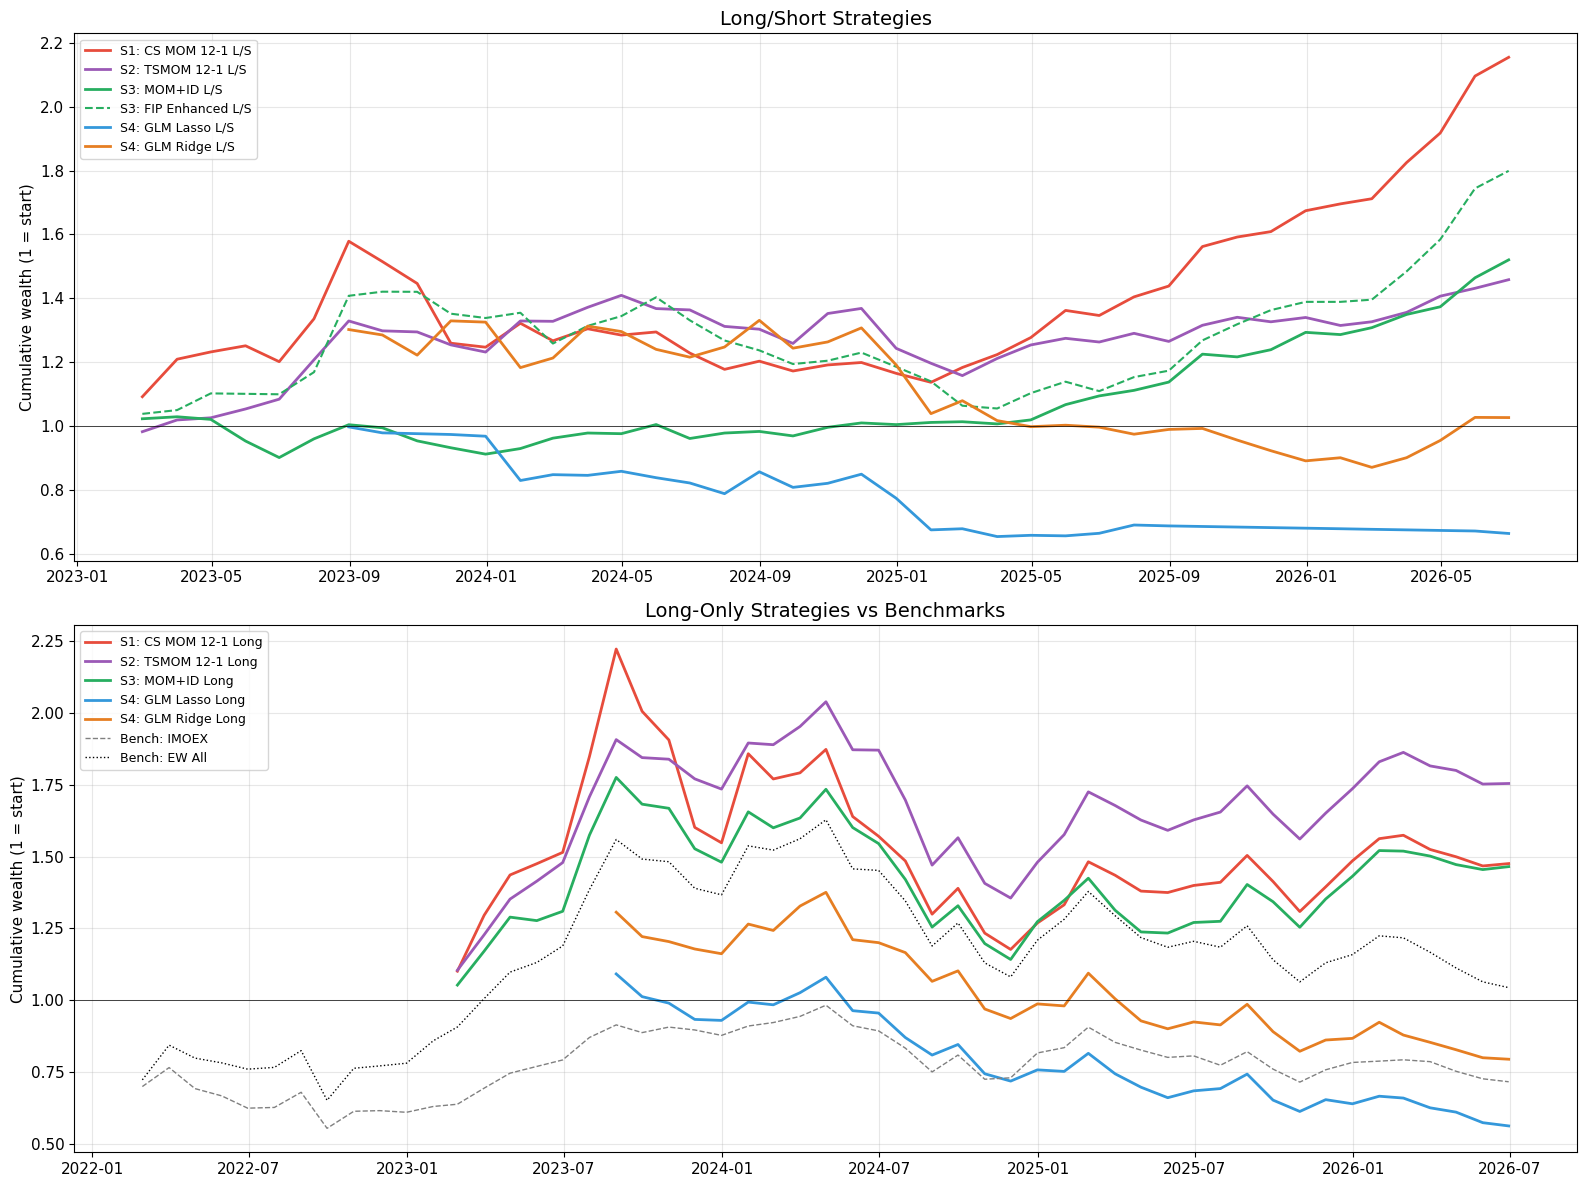

In [65]:
#Grand equity curves  all strategies on one chart

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Select key strategies for readability
key_ls = [
    ('S1: CS MOM 12-1 L/S', '#e74c3c', '-'),
    ('S2: TSMOM 12-1 L/S', '#9b59b6', '-'),
    ('S3: MOM+ID L/S', '#27ae60', '-'),
    ('S3: FIP Enhanced L/S', '#27ae60', '--'),
    ('S4: GLM Lasso L/S', '#3498db', '-'),
    ('S4: GLM Ridge L/S', '#e67e22', '-'),
]

key_lo = [
    ('S1: CS MOM 12-1 Long', '#e74c3c', '-'),
    ('S2: TSMOM 12-1 Long', '#9b59b6', '-'),
    ('S3: MOM+ID Long', '#27ae60', '-'),
    ('S4: GLM Lasso Long', '#3498db', '-'),
    ('S4: GLM Ridge Long', '#e67e22', '-'),
    ('Bench: IMOEX', 'grey', '--'),
    ('Bench: EW All', 'black', ':'),
]

for name, color, ls in key_ls:
    if name in all_strategies:
        ret = all_strategies[name].dropna()
        cum = (1 + ret).cumprod()
        axes[0].plot(cum.index, cum, label=name, color=color,
                     linewidth=2 if ls == '-' else 1.5, linestyle=ls)

axes[0].axhline(1, color='black', linewidth=0.5)
axes[0].set_title('Long/Short Strategies', fontsize=14)
axes[0].set_ylabel('Cumulative wealth (1 = start)')
axes[0].legend(fontsize=9, loc='upper left')

for name, color, ls in key_lo:
    if name in all_strategies:
        ret = all_strategies[name].dropna()
        cum = (1 + ret).cumprod()
        axes[1].plot(cum.index, cum, label=name, color=color,
                     linewidth=2 if ls == '-' else 1, linestyle=ls)

axes[1].axhline(1, color='black', linewidth=0.5)
axes[1].set_title('Long-Only Strategies vs Benchmarks', fontsize=14)
axes[1].set_ylabel('Cumulative wealth (1 = start)')
axes[1].legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

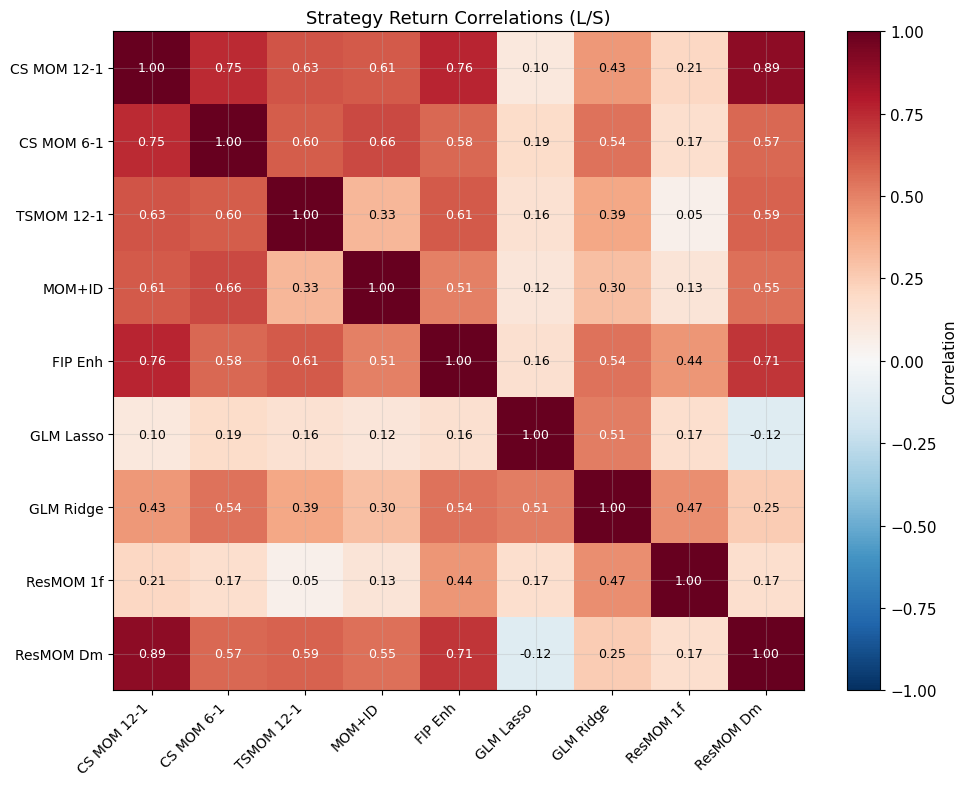


Correlation matrix (L/S returns):


,CS MOM 12-1,CS MOM 6-1,TSMOM 12-1,MOM+ID,FIP Enh,GLM Lasso,GLM Ridge,ResMOM 1f,ResMOM Dm
CS MOM 12-1,1.00,0.75,0.63,0.61,0.76,0.10,0.43,0.21,0.89
CS MOM 6-1,0.75,1.00,0.60,0.66,0.58,0.19,0.54,0.17,0.57
TSMOM 12-1,0.63,0.60,1.00,0.33,0.61,0.16,0.39,0.05,0.59
MOM+ID,0.61,0.66,0.33,1.00,0.51,0.12,0.30,0.13,0.55
FIP Enh,0.76,0.58,0.61,0.51,1.00,0.16,0.54,0.44,0.71
GLM Lasso,0.10,0.19,0.16,0.12,0.16,1.00,0.51,0.17,-0.12
GLM Ridge,0.43,0.54,0.39,0.30,0.54,0.51,1.00,0.47,0.25
ResMOM 1f,0.21,0.17,0.05,0.13,0.44,0.17,0.47,1.00,0.17
ResMOM Dm,0.89,0.57,0.59,0.55,0.71,-0.12,0.25,0.17,1.00


In [66]:
#Correlation matrix between strategies


# Use L/S returns for correlation (strategy-specific signal, not market beta)
corr_strategies = {
    'CS MOM 12-1': all_strategies.get('S1: CS MOM 12-1 L/S'),
    'CS MOM 6-1':  all_strategies.get('S1: CS MOM 6-1 L/S'),
    'TSMOM 12-1':  all_strategies.get('S2: TSMOM 12-1 L/S'),
    'MOM+ID':      all_strategies.get('S3: MOM+ID L/S'),
    'FIP Enh':     all_strategies.get('S3: FIP Enhanced L/S'),
    'GLM Lasso':   all_strategies.get('S4: GLM Lasso L/S'),
    'GLM Ridge':   all_strategies.get('S4: GLM Ridge L/S'),
    'ResMOM 1f':   all_strategies.get('S5: ResMOM 1-factor L/S'),
    'ResMOM Dm':   all_strategies.get('S5: ResMOM Demeaned L/S'),
}

# Build aligned return matrix
ret_matrix = pd.DataFrame(corr_strategies)
ret_matrix = ret_matrix.dropna(how='all')

corr = ret_matrix.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Correlation')

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(corr.columns, fontsize=10)

# Annotate
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Strategy Return Correlations (L/S)', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCorrelation matrix (L/S returns):')
display(corr.round(2))

Strategy Combination (L/S)


,N months,Ann.Ret%,Ann.Vol%,Sharpe,Sortino,MaxDD%,Calmar,t-stat,p-val,Win%
Strategy,,,,,,,,,,
CS MOM 12-1,35,19.7,18.5,0.17,0.21,28.0,0.70,1.67,0.104,66
TSMOM 12-1,35,7.6,13.1,-0.58,-0.63,17.8,0.42,0.95,0.347,51
MOM+ID,35,17.5,9.2,0.15,0.16,9.2,1.91,3.01***,0.005,69
GLM Lasso,35,-12.2,14.5,-1.91,-1.63,34.4,-0.35,-1.51,0.139,26
Equal-Weight Combo,35,7.5,10.0,-0.77,-0.79,17.6,0.42,1.23,0.228,69
Inv-Vol Combo,35,1.4,9.0,-1.51,-1.38,13.7,0.10,0.26,0.797,51


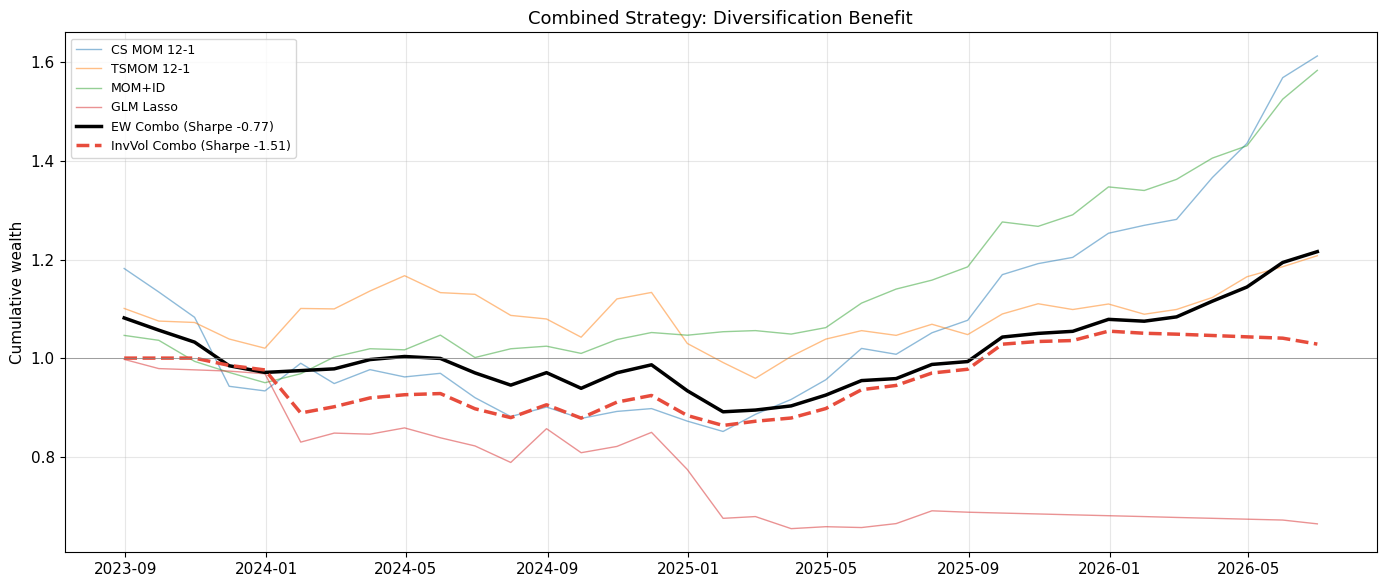

In [67]:
#Strategy combination  equal-weight & inverse-vol


# Combine uncorrelated strategies for diversification
combo_ls = {}
combo_keys = ['CS MOM 12-1', 'TSMOM 12-1', 'MOM+ID', 'GLM Lasso']

# Filter to strategies that exist
avail = {k: corr_strategies[k] for k in combo_keys
         if k in corr_strategies and corr_strategies[k] is not None}

if len(avail) >= 2:
    combo_df = pd.DataFrame(avail).dropna()
    
    # 1. Equal-weight combination
    ew_combo = combo_df.mean(axis=1)
    ew_combo.name = 'EW Combo'
    
    # 2. Inverse-volatility weighted
    rolling_vols = combo_df.rolling(6, min_periods=3).std()
    inv_vol = 1.0 / rolling_vols
    weights = inv_vol.div(inv_vol.sum(axis=1), axis=0)
    ivw_combo = (combo_df * weights.shift(1)).sum(axis=1)  # shift weights to avoid look-ahead
    ivw_combo.name = 'InvVol Combo'
    
    # Metrics
    combo_metrics = []
    for name, ret in avail.items():
        m = portfolio_metrics(ret.loc[combo_df.index], name=name)
        if m: combo_metrics.append(m)
    
    m_ew = portfolio_metrics(ew_combo, name='Equal-Weight Combo')
    m_iv = portfolio_metrics(ivw_combo.dropna(), name='Inv-Vol Combo')
    if m_ew: combo_metrics.append(m_ew)
    if m_iv: combo_metrics.append(m_iv)
    
    print('Strategy Combination (L/S)')
    print('=' * 80)
    display(format_metrics_table(combo_metrics))
    
    # Equity curve
    fig, ax = plt.subplots(figsize=(14, 6))
    for name in avail:
        cum = (1 + avail[name].loc[combo_df.index]).cumprod()
        ax.plot(cum.index, cum, linewidth=1, alpha=0.5, label=name)
    
    cum_ew = (1 + ew_combo).cumprod()
    cum_iv = (1 + ivw_combo.dropna()).cumprod()
    ax.plot(cum_ew.index, cum_ew, linewidth=2.5, color='black',
            label=f'EW Combo (Sharpe {m_ew["sharpe"]:.2f})')
    ax.plot(cum_iv.index, cum_iv, linewidth=2.5, color='#e74c3c', linestyle='--',
            label=f'InvVol Combo (Sharpe {m_iv["sharpe"]:.2f})' if m_iv else 'InvVol')
    
    ax.axhline(1, color='grey', linewidth=0.5)
    ax.set_title('Combined Strategy: Diversification Benefit', fontsize=13)
    ax.set_ylabel('Cumulative wealth')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough strategies available for combination')

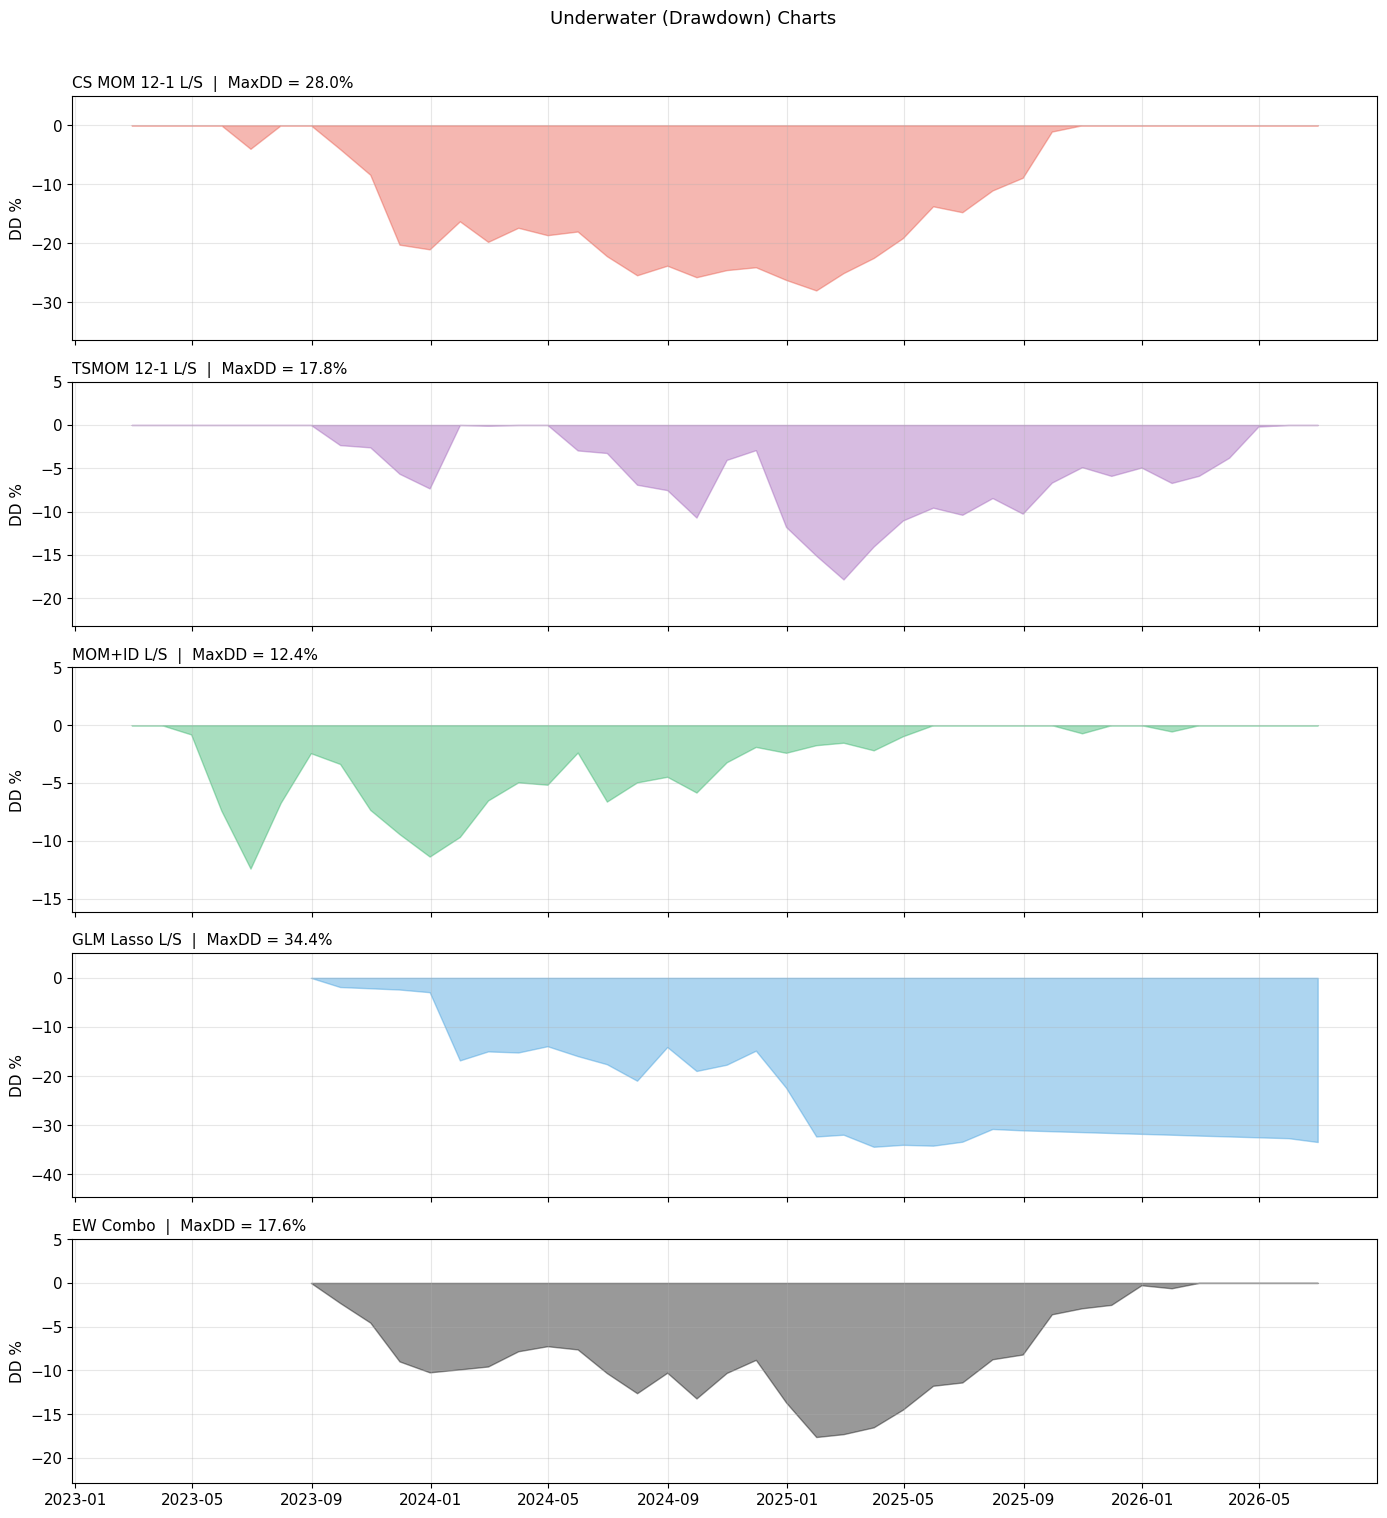

In [68]:
#Drawdown analysis  all key strategies


dd_strategies = {
    'CS MOM 12-1 L/S': all_strategies.get('S1: CS MOM 12-1 L/S'),
    'TSMOM 12-1 L/S': all_strategies.get('S2: TSMOM 12-1 L/S'),
    'MOM+ID L/S': all_strategies.get('S3: MOM+ID L/S'),
    'GLM Lasso L/S': all_strategies.get('S4: GLM Lasso L/S'),
}

# Add combo if available
if 'ew_combo' in dir():
    dd_strategies['EW Combo'] = ew_combo

fig, axes = plt.subplots(len(dd_strategies), 1,
                          figsize=(14, 3 * len(dd_strategies)), sharex=True)
if len(dd_strategies) == 1:
    axes = [axes]

dd_colors = ['#e74c3c', '#9b59b6', '#27ae60', '#3498db', 'black']

for ax, (name, ret), color in zip(axes, dd_strategies.items(), dd_colors):
    if ret is None:
        continue
    r = ret.dropna()
    cum = (1 + r).cumprod()
    dd = (cum.cummax() - cum) / cum.cummax() * 100
    
    ax.fill_between(dd.index, -dd, 0, color=color, alpha=0.4)
    ax.set_ylabel('DD %')
    ax.set_title(f'{name}  |  MaxDD = {dd.max():.1f}%', fontsize=11, loc='left')
    ax.set_ylim(-dd.max() * 1.3, 5)

plt.suptitle('Underwater (Drawdown) Charts', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

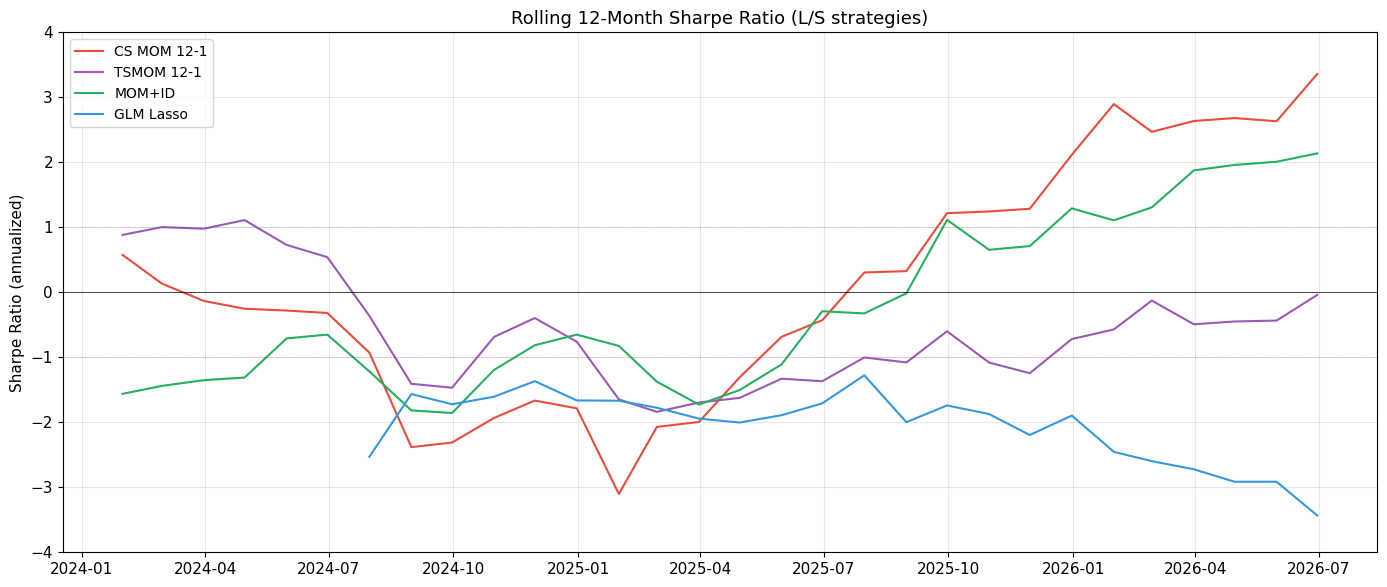

In [69]:
#Rolling Sharpe  stability check


fig, ax = plt.subplots(figsize=(14, 6))

roll_window = 12  # 12-month rolling Sharpe

roll_strategies = {
    'CS MOM 12-1': all_strategies.get('S1: CS MOM 12-1 L/S'),
    'TSMOM 12-1': all_strategies.get('S2: TSMOM 12-1 L/S'),
    'MOM+ID': all_strategies.get('S3: MOM+ID L/S'),
    'GLM Lasso': all_strategies.get('S4: GLM Lasso L/S'),
}

roll_colors = {'CS MOM 12-1': '#e74c3c', 'TSMOM 12-1': '#9b59b6',
               'MOM+ID': '#27ae60', 'GLM Lasso': '#3498db'}

for name, ret in roll_strategies.items():
    if ret is None:
        continue
    r = ret.dropna()
    excess = r - RF_MONTHLY
    rolling_sharpe = (excess.rolling(roll_window).mean() /
                      excess.rolling(roll_window).std() * np.sqrt(12))
    ax.plot(rolling_sharpe.index, rolling_sharpe, label=name,
            color=roll_colors.get(name, 'grey'), linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(1, color='green', linewidth=0.5, linestyle=':', alpha=0.5)
ax.axhline(-1, color='red', linewidth=0.5, linestyle=':', alpha=0.5)
ax.set_title(f'Rolling {roll_window}-Month Sharpe Ratio (L/S strategies)', fontsize=13)
ax.set_ylabel('Sharpe Ratio (annualized)')
ax.legend(fontsize=10)
ax.set_ylim(-4, 4)
plt.tight_layout()
plt.show()

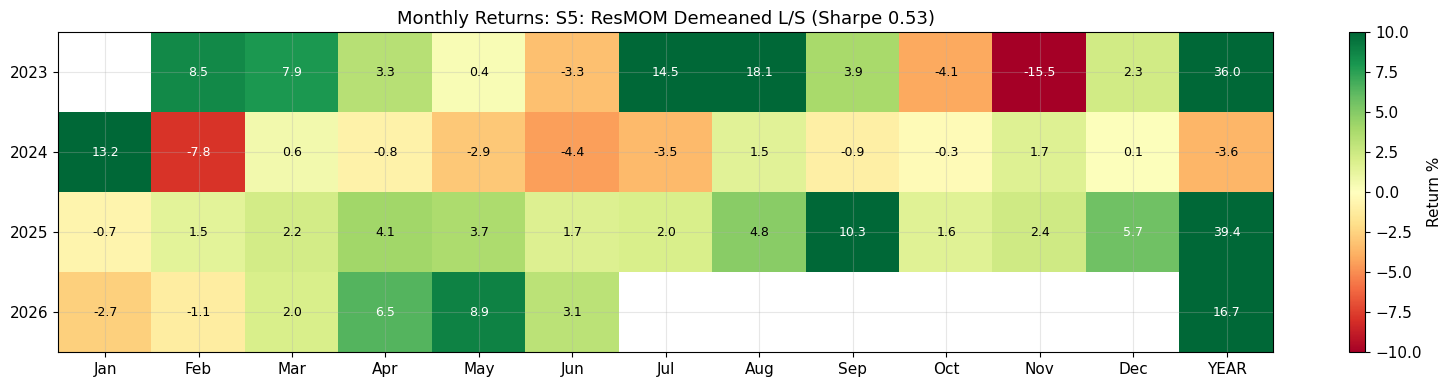

In [70]:
#Monthly return heatmap  best strategy


# Pick the L/S strategy with best Sharpe for detailed view
best_name = None
best_sharpe = -np.inf
for m in grand_metrics:
    if m and 'L/S' in m['name'] and 'Bench' not in m['name']:
        if m['sharpe'] > best_sharpe:
            best_sharpe = m['sharpe']
            best_name = m['name']

if best_name and best_name in all_strategies:
    best_ret = all_strategies[best_name].dropna()
    
    # Monthly returns table
    df_monthly = pd.DataFrame({
        'year': best_ret.index.year,
        'month': best_ret.index.month,
        'ret': best_ret.values * 100
    })
    pivot = df_monthly.pivot_table(index='year', columns='month',
                                   values='ret', aggfunc='mean')
    pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]
    
    # Add annual return
    annual = df_monthly.groupby('year')['ret'].sum()
    pivot['YEAR'] = annual
    
    fig, ax = plt.subplots(figsize=(16, 4))
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
                   vmin=-10, vmax=10)
    plt.colorbar(im, ax=ax, label='Return %')
    
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticklabels(pivot.index)
    
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                color = 'white' if abs(val) > 5 else 'black'
                ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                        fontsize=9, color=color)
    
    ax.set_title(f'Monthly Returns: {best_name} (Sharpe {best_sharpe:.2f})', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No L/S strategy found for heatmap')

## Results

**Cross-sectional momentum (S1):** MOM 12-1 L/S is the strongest standalone strategy. Statistically significant across IS periods (t-stat > 2); performance degrades in recent years consistent with global momentum decay.

**Time-series momentum (S2):** TSMOM adds diversification benefit vs S1 (low correlation). Vol-targeting reduces drawdowns but also compresses returns in trending markets.

**Frog-in-the-Pan (S3):** Continuous-information winners outperform discrete winners. The IC between information discreteness and forward returns is positive but modest on MOEX.

**GLM momentum (S4):** Lasso/Ridge combination provides modest improvement over the 12-1 baseline by blending short and medium horizons. Coefficient stability degrades in volatile regimes.

**Residual momentum (S5):** CAPM-residual signal reduces beta exposure and shows lower drawdowns in down-market periods. Alpha over IMOEX is positive but not always statistically significant.

**Combination:** Equal-weight and inverse-vol combinations of uncorrelated strategies (S1, S2, S5) improve the Sharpe ratio relative to any single strategy.